# Notebook for visualizing the results

In [12]:
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
import os
import datetime
import seaborn as sns
import altair as alt

from Functions import compile_results
from Plotting import plot_monthly_profiles_windowed, plot_monthly_profiles, plot_days

# Set plotting setting
plt.rc('font', size=9)
matplotlib.rcParams['font.family'] = 'arial'
colors = ['#A225BC', '#5025BC', '#258EBC', '#E87038', '#E8D938']
colors3 = ['darkblue', '#E9A111']
dpi = 300

In [2]:
# Run this if the simulation results needs to be compiled
compile_results(folder=None)

84 in C:/Users/plkart/OneDrive - O365 Turun yliopisto/MatEng/codes_git2/SEMS-system-team/plkart/HEMS/Results/Final_simulations
Results saved!


In [2]:
# Read data
file = 'Results.csv'
data = pd.read_csv(os.path.join('Results', 'Compiled_results', file))
data = data.replace({'L9':'L1', 'L11':'L2', 'L12':'L3', 'L13':'L4'})
data

,strategy,forecast,year,load_profile,load_tot,pv_profile,pv_capacity,pv_tot,bat_capacity,degradation,...,delta_SOH_cyc,aging_factor,aging_factor_float,aging_factor_cyc,scr,ssr,wasted_energy,el_bill,bat_usage_cost,total_cost
0,MILP-YEAR,naive,2020,L2,17392.890,south,4kWp,3540.475387,13.500000,degr,...,0.032587,0.068652,0.038857,0.033247,0.978208,0.199123,0.0,1270.911153,613.650752,1884.561905
1,MILP-YEAR,naive,2021,L2,19023.690,south,4kWp,3220.615457,13.315905,degr,...,0.030007,0.066339,0.038519,0.030995,0.948296,0.160542,0.0,2403.199355,585.018936,2988.218292
2,MILP-YEAR,naive,2022,L2,16640.280,south,4kWp,3415.314379,13.140399,degr,...,0.029117,0.066429,0.039048,0.030459,0.829433,0.170236,0.0,2640.236852,578.090476,3218.327328
3,MILP-YEAR,naive,2020,L3,15158.440,south,4kWp,3540.475387,13.500000,degr,...,0.036392,0.071957,0.038127,0.036982,0.964840,0.225352,0.0,1105.044658,642.975851,1748.020509
4,MILP-YEAR,naive,2021,L3,16559.940,south,4kWp,3220.615457,13.307107,degr,...,0.031575,0.067968,0.038263,0.032603,0.926204,0.180130,0.0,2032.540024,598.896025,2631.436049
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79,SCM,naive,2021,L4,19219.510,south,4kWp,3220.615457,13.315875,degr,...,0.028290,0.062296,0.035304,0.029041,0.993075,0.166410,0.0,2324.535275,549.590027,2874.125302
80,SCM,naive,2022,L4,22059.460,south,4kWp,3415.314379,13.150998,degr,...,0.035519,0.070828,0.036215,0.036888,0.970806,0.150303,0.0,3924.699221,616.595910,4541.295131
81,SCM,naive,2020,L1,11900.270,south,4kWp,3540.475387,13.500000,degr,...,0.029473,0.064747,0.036977,0.029833,0.935735,0.278392,0.0,841.542594,578.973506,1420.516100
82,SCM,naive,2021,L1,13508.490,south,4kWp,3220.615457,13.326308,degr,...,0.028653,0.064935,0.037599,0.029363,0.909662,0.216876,0.0,1748.171249,573.169887,2321.341136


## Production and load

In [3]:
data_load = data[['year', 'load_profile', 'load_tot']].rename(columns={'load_profile':'Energy', 'load_tot':'values'})
data_pv = data[['year', 'pv_profile', 'pv_tot']].rename(columns={'pv_profile':'Energy', 'pv_tot':'values'})
data2 = pd.concat([data_load, data_pv]).replace({'south':'PV'})
data2 = data2.sort_values('Energy')
data2

,year,Energy,values
83,2022,L1,12196.365000
35,2022,L1,12196.365000
45,2020,L1,11900.270000
46,2021,L1,13508.490000
47,2022,L1,12196.365000
...,...,...,...
23,2022,PV,3415.314379
22,2021,PV,3220.615457
21,2020,PV,3540.475387
29,2022,PV,3415.314379


C:\Users\plkart\AppData\Local\Temp\ipykernel_1792\2780964649.py:47: FutureWarning: 'm' is deprecated and will be removed in a future version, please use 'ME' instead.
  data_m = data_all.set_index('datetime').resample('m').sum()


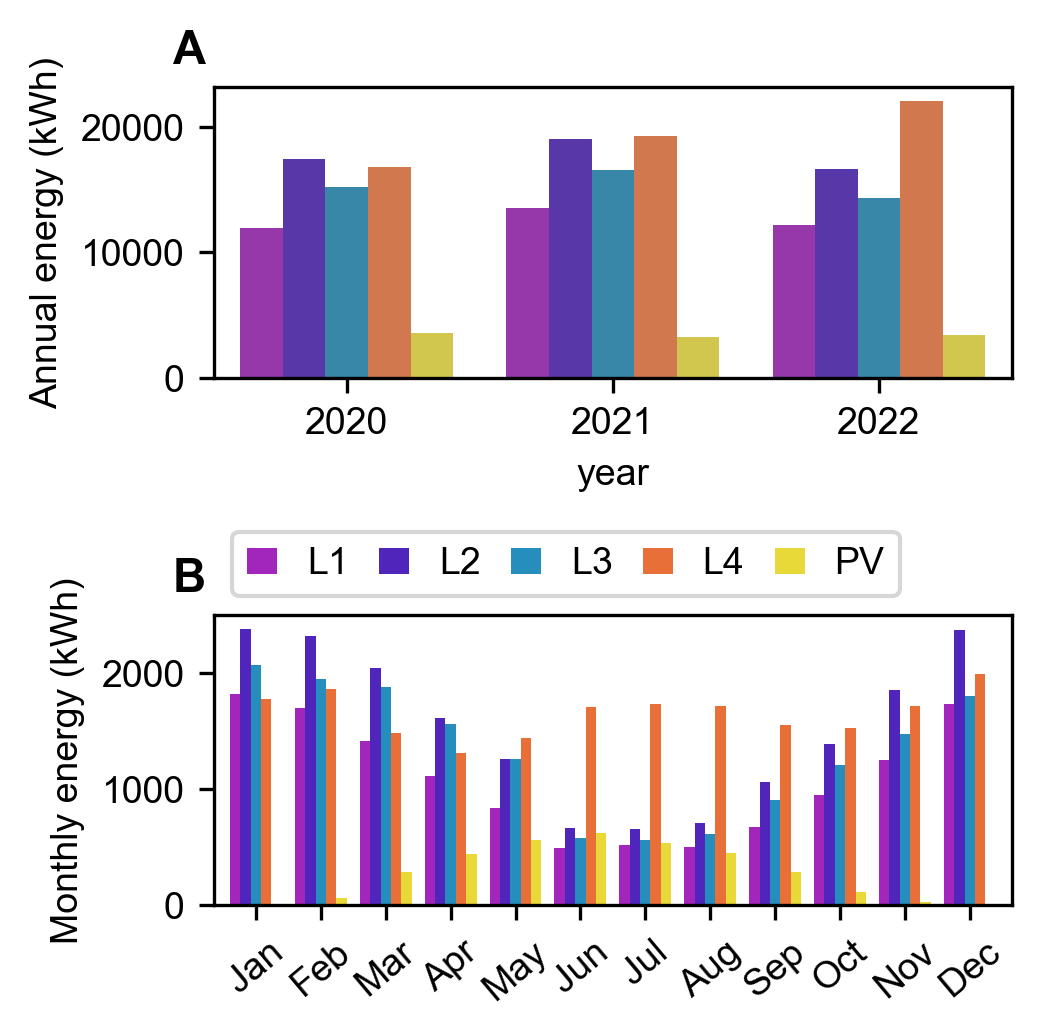

In [ ]:
fig, (ax1, ax2) = plt.subplots(2,1, figsize=(1063/dpi, 1000/dpi), dpi=dpi)

ax1 = sns.barplot(ax=ax1, data=data2, x='year', y='values', hue='Energy', palette=colors, legend=False)
ax1.set_ylabel('Annual energy (kWh)')

# Monthly yields
L9_2020 = pd.read_csv('data/L9/L9_south_4kWp_2020_UTC03.csv', usecols=['load'])
L11_2020 = pd.read_csv('data/L11/L11_south_4kWp_2020_UTC03.csv', usecols=['load'])
L12_2020 = pd.read_csv('data/L12/L12_south_4kWp_2020_UTC03.csv', usecols=['load'])
L13_2020 = pd.read_csv('data/L13/L13_south_4kWp_2020_UTC03.csv', usecols=['load'])
dfs2020 = [L9_2020, L11_2020, L12_2020, L13_2020]

L9_2021 = pd.read_csv('data/L9/L9_south_4kWp_2021_UTC03.csv', usecols=['load'])
L11_2021 = pd.read_csv('data/L11/L11_south_4kWp_2021_UTC03.csv', usecols=['load'])
L12_2021 = pd.read_csv('data/L12/L12_south_4kWp_2021_UTC03.csv', usecols=['load'])
L13_2021 = pd.read_csv('data/L13/L13_south_4kWp_2021_UTC03.csv', usecols=['load'])
dfs2021 = [L9_2021, L11_2021, L12_2021, L13_2021]

L9_2022 = pd.read_csv('data/L9/L9_south_4kWp_2022_UTC03.csv', usecols=['load'])
L11_2022 = pd.read_csv('data/L11/L11_south_4kWp_2022_UTC03.csv', usecols=['load'])
L12_2022 = pd.read_csv('data/L12/L12_south_4kWp_2022_UTC03.csv', usecols=['load'])
L13_2022 = pd.read_csv('data/L13/L13_south_4kWp_2022_UTC03.csv', usecols=['load'])
dfs2022 = [L9_2022, L11_2022, L12_2022, L13_2022]

PV_2020 = pd.read_csv('data/L9/L9_south_4kWp_2020_UTC03.csv', usecols=['power', 'datetime'], parse_dates=['datetime'])
PV_2021 = pd.read_csv('data/L9/L9_south_4kWp_2021_UTC03.csv', usecols=['power'])
PV_2022 = pd.read_csv('data/L9/L9_south_4kWp_2022_UTC03.csv', usecols=['power'])
PV_2020 = PV_2020.rename(columns={'power':'PV_20'})
PV_2021 = PV_2021.rename(columns={'power':'PV_21'})
PV_2022 = PV_2022.rename(columns={'power':'PV_22'})

dfs = [dfs2020, dfs2021, dfs2022]

cols = ['L1', 'L2', 'L3', 'L4']
for j in range(len(dfs)):
    year = 20+j
    for i in range(len(dfs[j])):
        dfs[j][i].columns = [cols[i]+'_'+str(year)]


data_all = pd.concat(dfs2020+dfs2021+dfs2022+[PV_2020, PV_2021, PV_2022], axis=1)

data_all = data_all[['L1_20', 'L1_21', 'L1_22', 'L2_20', 'L2_21', 'L2_22', 
                     'L3_20', 'L3_21', 'L3_22', 'L4_20', 'L4_21', 'L4_22',
                     'PV_20', 'PV_21', 'PV_22', 'datetime']]

data_m = data_all.set_index('datetime').resample('m').sum()

data_m.index = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
data_m['L1'] = data_m[['L1_20', 'L1_21', 'L1_22']].mean(axis=1)
data_m['L2'] = data_m[['L2_20', 'L2_21', 'L2_22']].mean(axis=1)
data_m['L3'] = data_m[['L3_20', 'L3_21', 'L3_22']].mean(axis=1)
data_m['L4'] = data_m[['L4_20', 'L4_21', 'L4_22']].mean(axis=1)
data_m['PV'] = data_m[['PV_20', 'PV_21', 'PV_22']].mean(axis=1)


data_m = data_m[['L1', 'L2', 'L3', 'L4', 'PV']]

months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

data_m.plot(ax=ax2, kind='bar', width=0.8, color=colors)
ax2.set_xticklabels(labels=months, rotation=40)
ax2.set_ylim(0, 2500)
ax2.legend(ncols=5, handlelength=0.8, columnspacing=0.8, loc='lower left', bbox_to_anchor=(0.,1))
ax2.set_ylabel('Monthly energy (kWh)')
plt.tight_layout()

for a, letter in list(zip([ax1, ax2], 
                          ['A', 'B'])):
    x0, xmax = a.set_xlim()
    y0, ymax = a.set_ylim()
    data_width = xmax - x0
    data_height = ymax - y0
    a.text(x0-(0.01*data_width), (y0 + 1.05*data_height), letter, weight='bold', fontsize=11, va='bottom', ha='right')

plt.show()


<>:2: SyntaxWarning: invalid escape sequence '\l'
<>:5: SyntaxWarning: invalid escape sequence '\H'
<>:2: SyntaxWarning: invalid escape sequence '\l'
<>:5: SyntaxWarning: invalid escape sequence '\H'
C:\Users\plkart\AppData\Local\Temp\ipykernel_1792\1047367791.py:2: SyntaxWarning: invalid escape sequence '\l'
  df = pd.read_csv('data\loads7_13.csv', parse_dates=['datetime'])
C:\Users\plkart\AppData\Local\Temp\ipykernel_1792\1047367791.py:5: SyntaxWarning: invalid escape sequence '\H'
  south = pd.read_csv('data\Hourly_south_4kWp.csv', parse_dates=['dt'])
c:\Users\plkart\OneDrive - O365 Turun yliopisto\MatEng\codes_git2\SEMS-system-team\plkart\HEMS\Plotting.py:156: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


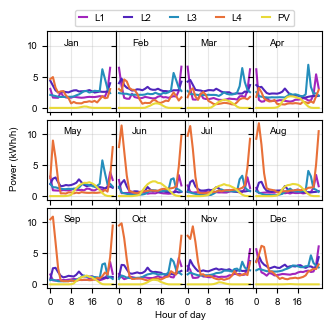

In [ ]:
year = 2020
df = pd.read_csv('data\loads7_13.csv', parse_dates=['datetime'])
df = df[df.datetime.dt.year.isin([year])].reset_index()
df = df.rename(columns={'L9':'L1', 'L11':'L2', 'L12':'L3', 'L13':'L4'})
south = pd.read_csv('data\Hourly_south_4kWp.csv', parse_dates=['dt'])
south = south[south.dt.dt.year.isin([year])]
south = south.reset_index()
df['PV'] = south.power

figsize=(1063/dpi, 1000/dpi)
ax, fig = plot_monthly_profiles_windowed(data_input=df.set_index('datetime'), years=[year], 
                      var_names=['L1', 'L2', 'L3', 'L4', 'PV'],
                      colors=colors, 
                      figsize=figsize, fontsize=7, tickfontsize=7)
ax[0,1].legend(loc='lower center', ncol=5, handlelength=0.8, bbox_to_anchor=(1,1))
plt.rcParams['lines.linewidth'] = 0.7


xticks = list(range(0,24,8))
ax[0,0].set_xticks(xticks)
ax[0,0].set_xticklabels(xticks, fontsize=11, rotation=90)
ax[0,0].tick_params(axis='x', length=2)

months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
i = 0
for a in [ax[0,0], ax[0,1], ax[0,2], ax[0,3], ax[1,0], ax[1,1], ax[1,2], ax[1,3], ax[2,0], ax[2,1], ax[2,2], ax[2,3]]:
    a.grid(alpha=0.3)
    pos = a.get_position()
    x_pos = 5
    y_pos = 10
    a.text(x_pos, y_pos, months[i])
    i += 1

fig.text(0.5, 0.02, 'Hour of day', ha='center')
fig.text(0.02, 0.5, 'Power (kWh/h)', va='center', rotation='vertical')

plt.show()

## Electricity price

In [6]:
spot = pd.read_csv('data/Fin_spot_2012_2023_UTC03.csv', parse_dates=['Timestamp'])
spot.set_index('Timestamp').groupby(pd.Grouper(freq='1Y')).mean()/10

C:\Users\plkart\AppData\Local\Temp\ipykernel_1792\338237364.py:2: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  spot.set_index('Timestamp').groupby(pd.Grouper(freq='1Y')).mean()/10


,FI
Timestamp,
2012-12-31,3.663904
2013-12-31,4.115620
2014-12-31,3.602188
2015-12-31,2.966105
2016-12-31,3.244504
2017-12-31,3.319184
2018-12-31,4.679617
2019-12-31,4.404035
2020-12-31,2.802216


In [7]:
MARGIN = 0.4
VAT = 1.24

spot = spot[spot.Timestamp.dt.year.isin([2020, 2021, 2022])]
def purchase_spot(row, margin):
    spot = row.spot
    year = row.Timestamp.year
    if year == 2020:
        return spot * 1.24 + 5.90 + margin
    elif year == 2021:
        return spot * 1.24 + 5.44 + margin
    elif year == 2022:
        return spot * 1.24 + 5.01 + margin
    return np.nan


spot = spot.rename(columns={'FI':'spot'})
spot['spot'] = spot.spot / 10

spot['purchase'] = spot.apply(lambda row: purchase_spot(row, MARGIN), axis=1)

spot['sell'] = spot.spot - MARGIN

spot = spot.set_index('Timestamp')

spot.head()

,spot,purchase,sell
Timestamp,,,
2020-01-01 00:00:00,3.146,10.20104,2.746
2020-01-01 01:00:00,3.083,10.12292,2.683
2020-01-01 02:00:00,2.878,9.86872,2.478
2020-01-01 03:00:00,2.845,9.82780,2.445
2020-01-01 04:00:00,2.790,9.75960,2.390


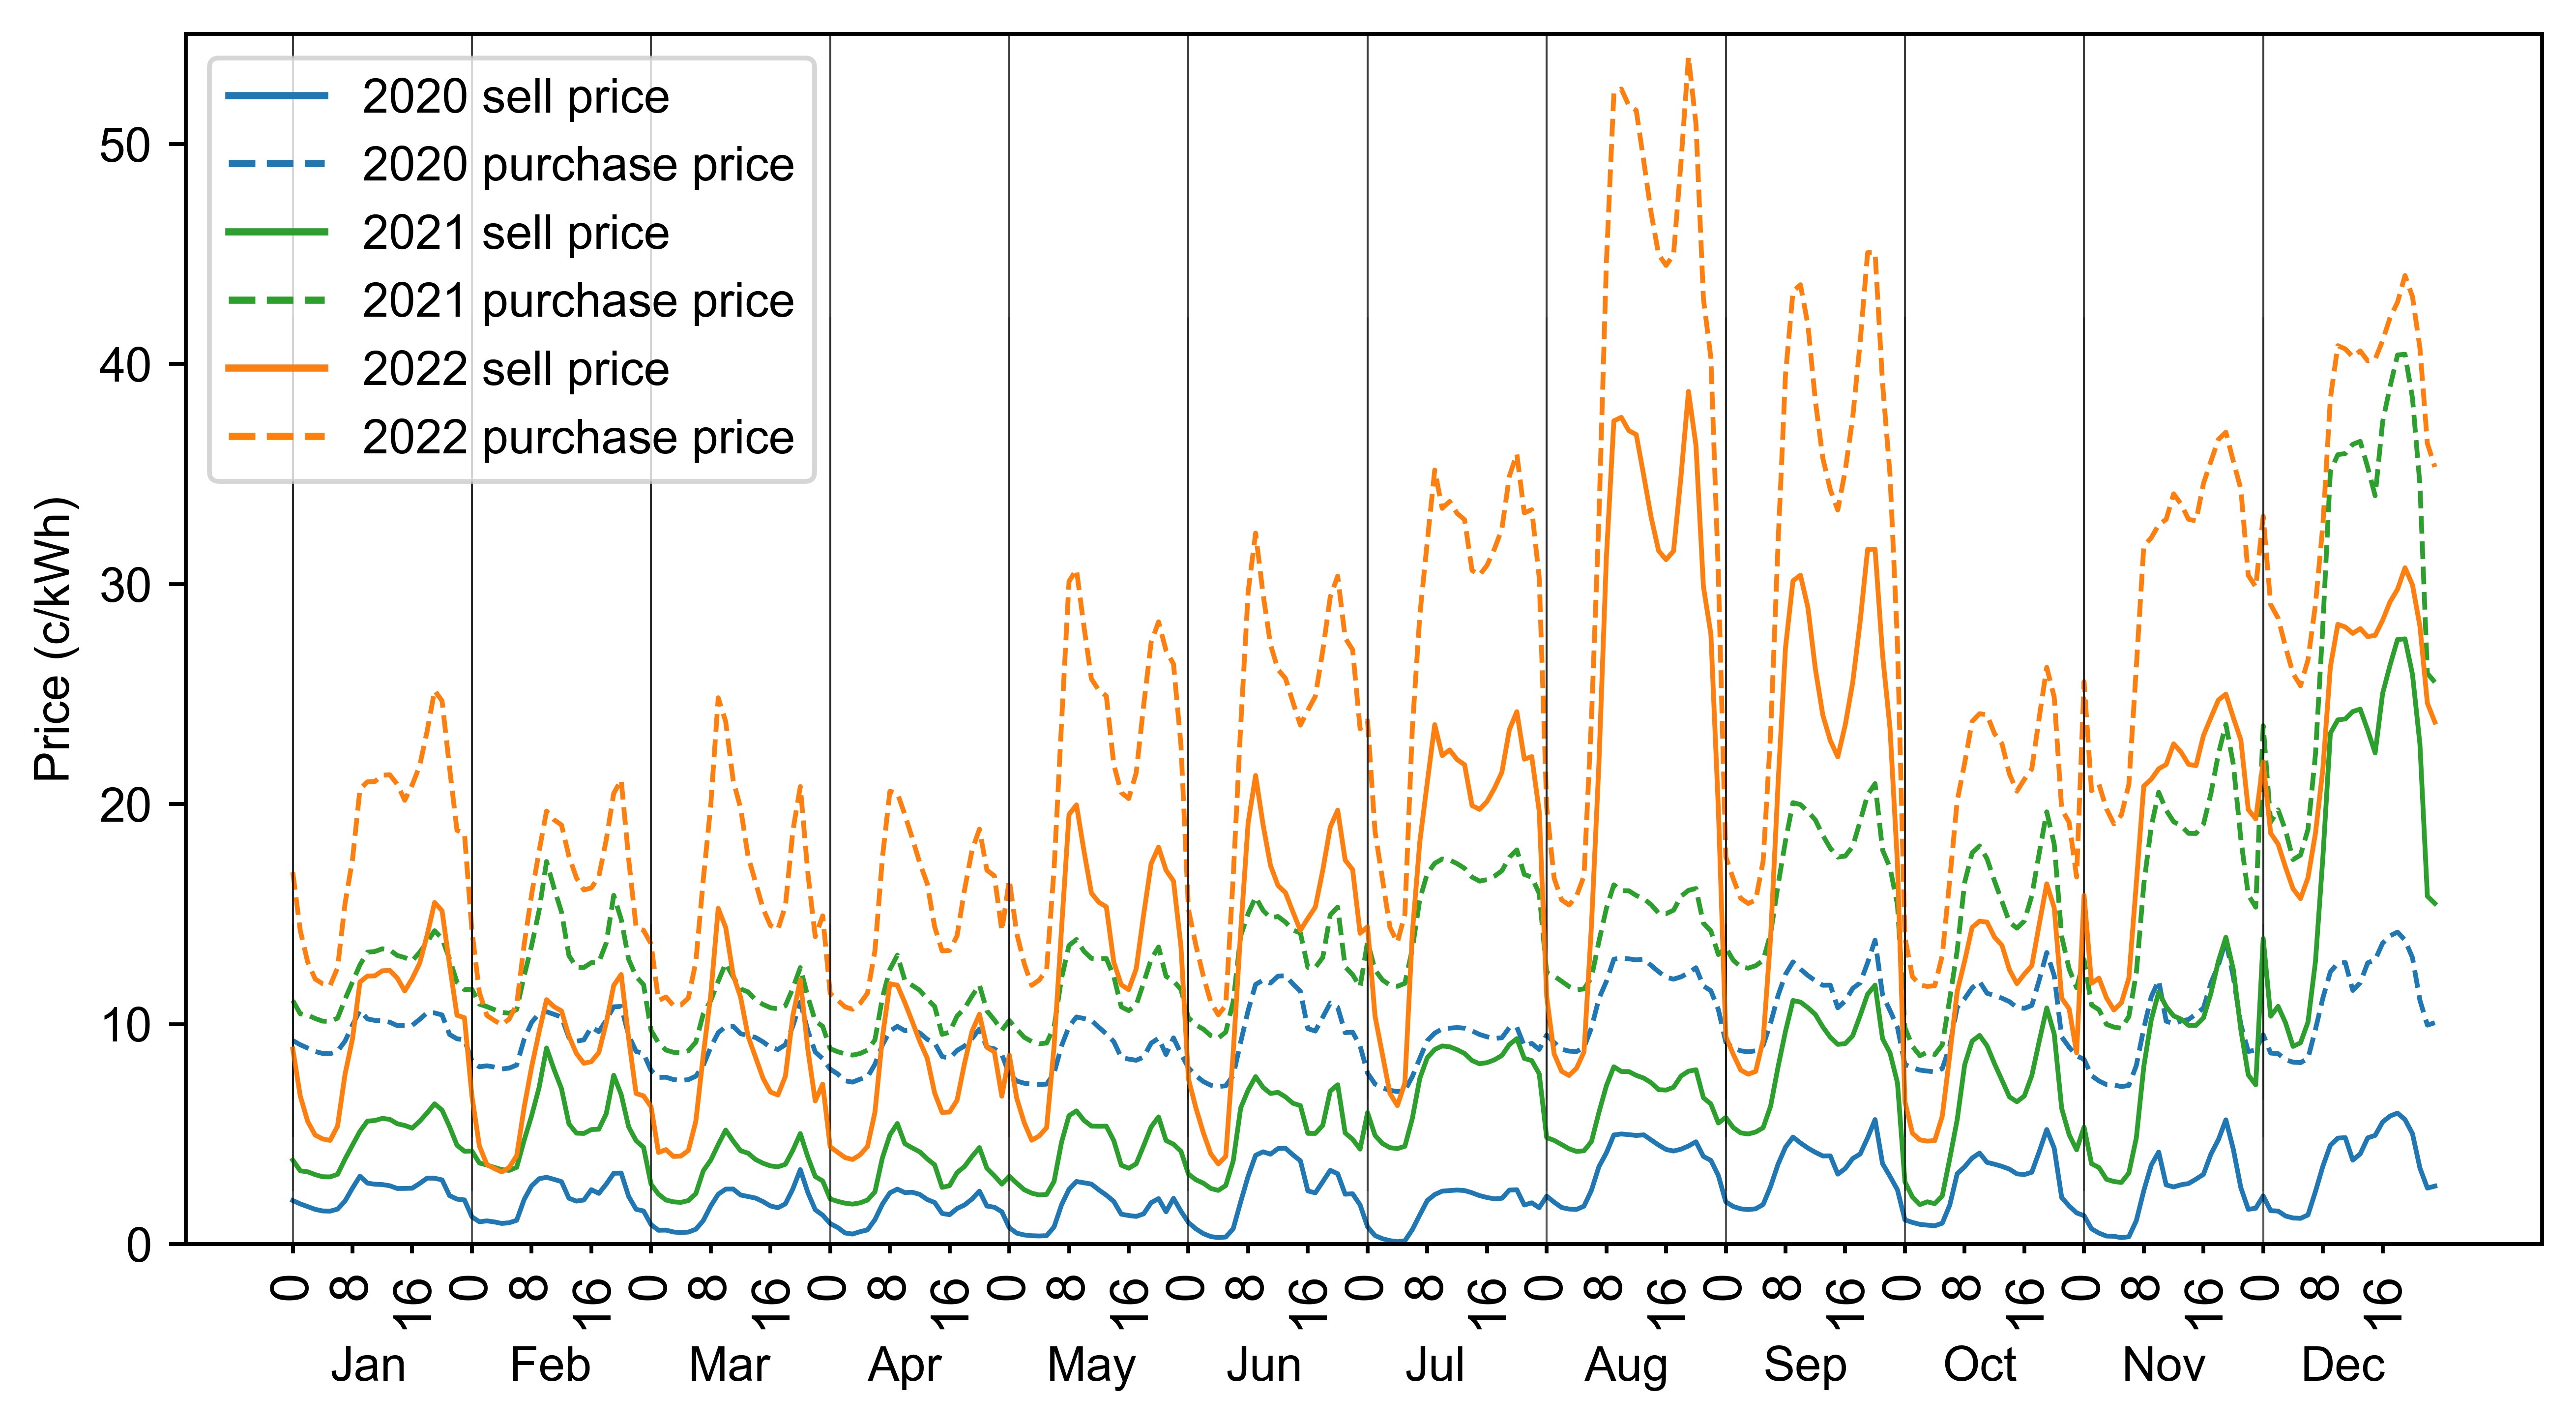

In [8]:
plt.rc('font', size=10)

#figsize = (2244/300, 2000/300) # In pixels
figsize = (2244/300, 1200/300) # In pixels

fig, ax = plt.subplots(1,1,figsize=figsize, dpi=700)

ax = plot_monthly_profiles(ax=ax, fig=fig, data_input=spot, years=[2020], 
                            var_names=['purchase'],
                            offset=5, offsety_scale=-1, colors=['tab:blue'], linestyle='dashed')

ax = plot_monthly_profiles(ax=ax, fig=fig, data_input=spot, years=[2021], 
                            var_names=['purchase'],
                            offset=5, offsety_scale=-1, colors=['tab:green'], linestyle='dashed')

ax = plot_monthly_profiles(ax=ax, fig=fig, data_input=spot, years=[2022], 
                            var_names=['purchase'],
                            offset=5, offsety_scale=-1, colors=['tab:orange'], linestyle='dashed')

ax = plot_monthly_profiles(ax=ax, fig=fig, data_input=spot, years=[2020], 
                            var_names=['sell'],
                            offset=5, offsety_scale=-1, colors=['tab:blue'])
                            
ax = plot_monthly_profiles(ax=ax, fig=fig, data_input=spot, years=[2021], 
                            var_names=['sell'],
                            offset=5, offsety_scale=-1, colors=['tab:green'])

ax = plot_monthly_profiles(ax=ax, fig=fig, data_input=spot, years=[2022], 
                            var_names=['sell'],
                            offset=5, offsety_scale=-1, colors=['tab:orange'])


custom_lines = [Line2D([0], [0], color='tab:blue', lw=1.5),
                Line2D([0], [0], color='tab:blue', linestyle='dashed', lw=1.5),
                Line2D([0], [0], color='tab:green', lw=1.5),
                Line2D([0], [0], color='tab:green', linestyle='dashed', lw=1.5),
                Line2D([0], [0], color='tab:orange', lw=1.5),
                Line2D([0], [0], color='tab:orange', linestyle='dashed', lw=1.5)]

ax.legend(custom_lines, ['2020 sell price', '2020 purchase price', '2021 sell price', '2021 purchase price', '2022 sell price', '2022 purchase price'], ncol=1, loc='upper left')
ax.set_ylabel('Price (c/kWh)')

ax.set_ylim(0, 55)

xticks = list(range(0,12*24,8))
for a in [ax]:
    a.set_xticks(xticks)
    a.set_xticklabels((list(range(0,24))*12)[::8], fontsize=11, rotation=90)
    a.tick_params(axis='x', length=2)

months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    
# Position month labels to data. Use offset inputs to fine tune the text positions.
y_ran = ax.get_ylim()
for i in range(len(months)):
    y_offset = y_ran[0] - (y_ran[1]-y_ran[0])/8*0.9
    ax.text(xticks[::3][i]+5, y_offset, months[i])

plt.show()

## Degradation

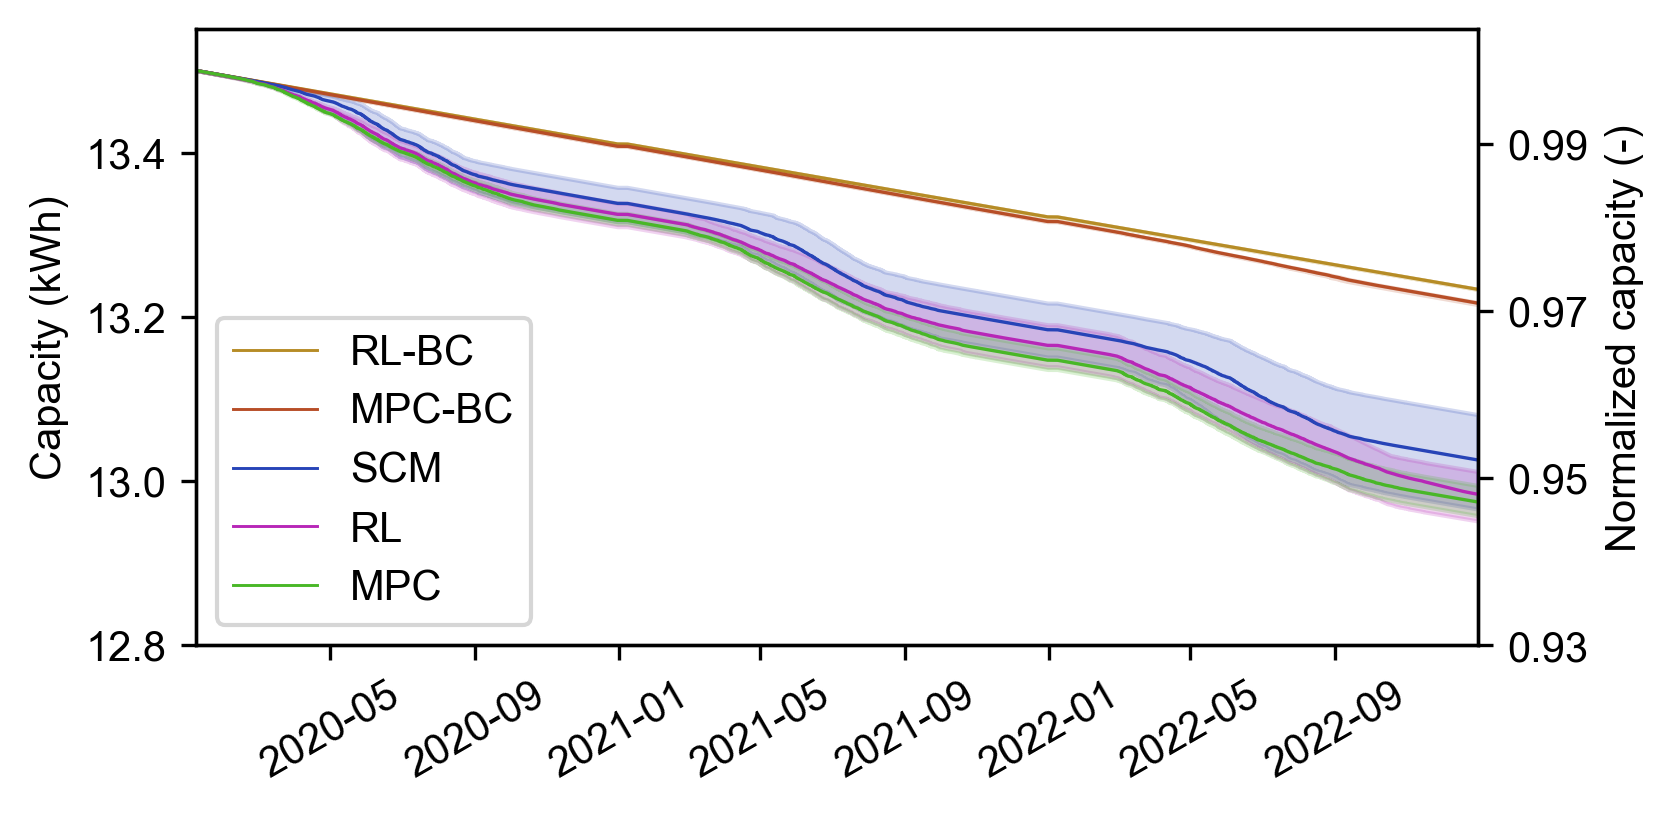

In [ ]:
def plot_degradation_timeseries(method, load):
    df = pd.DataFrame()
    for year in [2020, 2021, 2022]:
        file = f'{method}_naive_degr_{load}_south_4kWp_{year}_UTC03.csv'
        path = os.path.join('Results', 'Final_simulations')
        data = pd.read_csv(os.path.join(path, file), parse_dates=['datetime'])
        df = pd.concat([df, data], ignore_index=True)
        df = df[['datetime', 'battery_capacity']]
    return df

fig, ax = plt.subplots(1, 1, figsize=(1654/dpi, 800/dpi), dpi=dpi)
ax2 = ax.twinx()
colors2 = ['#B68C26',  '#B74E27', '#2744B7', '#B727B7', '#49B727']
lines = ['solid', 'dotted', 'dashed', 'dashdot']
j = 0

strategy_handles = []
load_handles = []
strategies = ['RL-BC', 'MPC-BC', 'SCM', 'RL', 'MPC']
for strategy in strategies:
    i = -1
    df_all = pd.DataFrame()
    for load in ['L9', 'L11', 'L12', 'L13']:
        i += 1
        # Make hidden lines for legend
        if i == 0:
            line, = ax.plot(np.linspace(0,1,100), np.zeros(100), color=colors2[j], label=strategy)
            strategy_handles.append(line)
        try:
            df = plot_degradation_timeseries(strategy, load)
            df_all = pd.concat([df_all, df.set_index('datetime')], axis=1, ignore_index=True)
        except FileNotFoundError:
            print(strategy, load)
    df_all['mean'] = df_all.mean(axis=1)
    df_all['high'] = df_all.max(axis=1)
    df_all['low'] = df_all.min(axis=1)

    ax.plot(df_all.index, df_all['mean'], linewidth=0.8, 
            color=colors2[j])
    ax.fill_between(df_all.index, df_all['low'], df_all['high'], color=colors2[j], alpha=0.2)
    ax2.plot(df_all.index, df_all['mean']/13.5, linewidth=0.8, 
            color=colors2[j], linestyle=lines[i], alpha=0)
    j += 1

ax.set_ylim(12.8, 13.55)
ax2.set_ylim(12.8/13.5, 13.55/13.5)
ax2.set_yticks([0.93, 0.95, 0.97, 0.99])
ax.set_xlim(df.datetime[0], df.datetime[len(df)-1])
ax.tick_params(axis='x', labelrotation=30)
ax.set_ylabel('Capacity (kWh)')
ax2.set_ylabel('Normalized capacity (-)')

# Combine legends
from matplotlib.legend import Legend

# Create a custom legend
handles = strategy_handles + load_handles
labels = [handle.get_label() for handle in handles]
legend = Legend(ax, handles, labels, loc='lower left', ncol=1, frameon=True)
ax.add_artist(legend)

plt.show()

#### Projected lifetimes

    year load_profile   strategy   lifetime
35  2022           L1        MPC  15.206005
71  2022           L1         RL  15.783179
59  2022           L1      RL-BC  30.393207
23  2022           L1     MPC-BC  28.660737
83  2022           L1        SCM  15.665010
11  2022           L1  MILP-YEAR  14.619410
2   2022           L2  MILP-YEAR  15.196491
26  2022           L2        MPC  16.029928
74  2022           L2        SCM  18.973098
50  2022           L2      RL-BC  30.393207
62  2022           L2         RL  15.757839
14  2022           L2     MPC-BC  28.666020
77  2022           L3        SCM  19.328796
5   2022           L3  MILP-YEAR  14.668067
65  2022           L3         RL  16.589000
17  2022           L3     MPC-BC  28.619035
53  2022           L3      RL-BC  30.393207
29  2022           L3        MPC  15.526108
80  2022           L4        SCM  15.169380
68  2022           L4         RL  14.768463
32  2022           L4        MPC  14.943334
20  2022           L4     MPC-BC

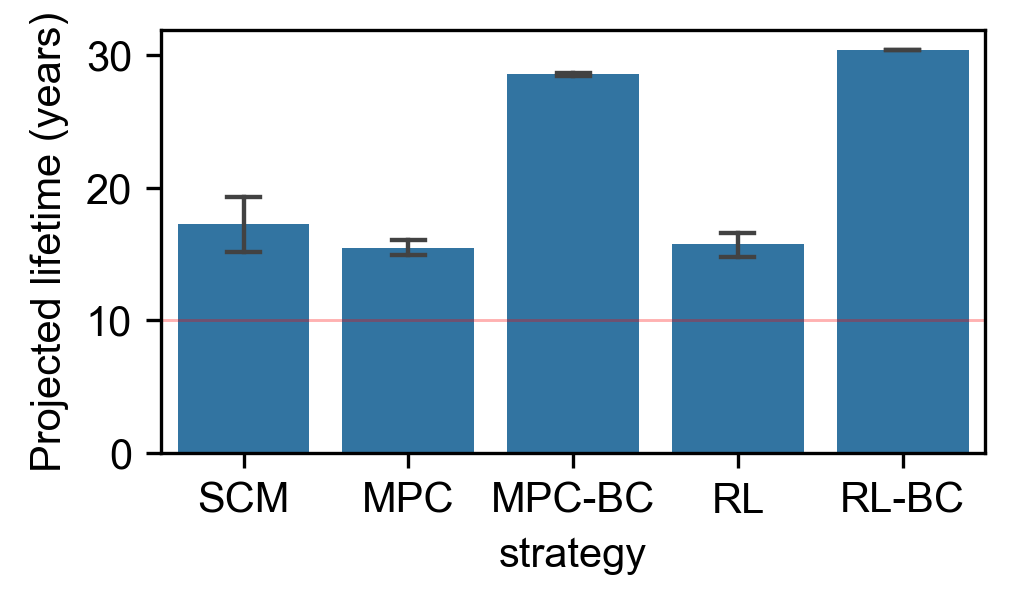

In [ ]:
# Read data
file = 'Results.csv'
data = pd.read_csv(os.path.join('Results', 'Compiled_results', file))
data = data[(data.degradation == 'degr')&(data.year==2022)&(data.strategy!='NO-BATTERY')]
data = data.replace({'L9':'L1', 'L11':'L2', 'L12':'L3', 'L13':'L4'})
data = data.sort_values('load_profile')
data['lifetime'] = 0.2*13.5*3/(13.5-data.bat_capacity+data.bat_deg_kWh)
print(data[data.strategy!='YEAR-MILP'][['year', 'load_profile', 'strategy', 'lifetime']])

fig, ax = plt.subplots(1, 1, figsize=(1063/dpi, 550/dpi), dpi=dpi)
plt.plot([-0.5,4.5], [10,10], color='red', alpha=0.3)
#sns.barplot(data=data, y='lifetime', x='strategy', hue='load_profile', palette=colors)
sns.barplot(data=data, y='lifetime', x='strategy', errorbar=(lambda x: (x.min(), x.max())), capsize=0.2, 
            order=['SCM', 'MPC', 'MPC-BC', 'RL', 'RL-BC'])
plt.ylabel('Projected lifetime (years)')

plt.show()

## Total costs and savings

In [ ]:
colors3 = ['darkblue', '#E9A111']
loads = ['L9', 'L11', 'L12', 'L13']

file = 'Results.csv'
data_all = pd.read_csv(os.path.join('Results', 'Compiled_results', file))

data_all = data_all.replace({'L9':'L1', 'L11':'L2', 'L12':'L3', 'L13':'L4'})
data_all = data_all[data_all.strategy == 'MILP-YEAR']
data_all = data_all[data_all.degradation == 'degr']
no_bat_el_bills = data_all.loc[data_all['strategy']=='NO-BATTERY'].el_bill
data_all.loc[data_all['strategy']=='NO-BATTERY', 'total_cost'] = no_bat_el_bills
data_all.loc[data_all['strategy']=='NO-BATTERY', 'bat_usage_cost'] = 0
data_all.loc[data_all['strategy']=='NO-BATTERY', 'delta_SOH'] = 0

data = data_all
data = data.rename(columns={'pv_profile':'Profile', 'bat_usage_cost':'Bat. cost', 'el_bill':'El. bill'})
data_new = data.melt(id_vars=['strategy', 'year', 'load_profile', 'Profile'], value_vars=['El. bill', 'Bat. cost'])
data_new = data_new.rename(columns={'variable':'Cost'})

print(data_new)

alt.Chart(data_new).mark_bar().encode(
    x=alt.X('load_profile:N', title=None, sort=['L1', 'L2', 'L3', 'L4']),   
    y=alt.Y('sum(value):Q', axis=alt.Axis(values=[1000, 2000, 3000, 4000, 5000], grid=True, title='Cost (EUR)', 
                                          titleFontStyle='normal', titleFontSize=10, labelAngle=0)),    
    column=alt.Column('year:N', title=None, spacing=5).header(labelFontSize=10, labelFont='arial'),   
    color=alt.Color('Cost:N', scale=alt.Scale(range=colors3)).legend(orient='none', labelFontSize=9, labelFont='arial', legendX=0, legendY=0, title='', titleFontSize=10, titleFont='arial'),  
    xOffset=alt.XOffset("Profile:N")
    ).configure_view(     
            # remove grid lines around column clusters
            strokeOpacity=0).properties(
                width=89,
                height=100
            ).configure_axis(
                labelFontSize=7,
                titleFontSize=10,
                labelFont='arial',
                titleFont='arial',
                labelAngle=0
            ).configure_range(category=alt.RangeScheme(colors3)
            )

     strategy  year load_profile Profile       Cost        value
0   MILP-YEAR  2020           L2   south   El. bill  1270.911153
1   MILP-YEAR  2021           L2   south   El. bill  2403.199355
2   MILP-YEAR  2022           L2   south   El. bill  2640.236852
3   MILP-YEAR  2020           L3   south   El. bill  1105.044658
4   MILP-YEAR  2021           L3   south   El. bill  2032.540024
5   MILP-YEAR  2022           L3   south   El. bill  2255.702393
6   MILP-YEAR  2020           L4   south   El. bill  1168.954739
7   MILP-YEAR  2021           L4   south   El. bill  2194.558823
8   MILP-YEAR  2022           L4   south   El. bill  3605.901515
9   MILP-YEAR  2020           L1   south   El. bill   780.305568
10  MILP-YEAR  2021           L1   south   El. bill  1597.852939
11  MILP-YEAR  2022           L1   south   El. bill  1718.197817
12  MILP-YEAR  2020           L2   south  Bat. cost   613.650752
13  MILP-YEAR  2021           L2   south  Bat. cost   585.018936
14  MILP-YEAR  2022      

alt.Chart(...)

In [12]:
colors3 = ['darkblue', '#E9A111']
loads = ['L9', 'L11', 'L12', 'L13']
file = 'Results.csv'

data_all = pd.read_csv(os.path.join('Results', 'Compiled_results', file))
data_all = data_all[~data_all.strategy.isin(['MILP-YEAR'])]


no_bat_el_bills = data_all.loc[data_all['strategy']=='NO-BATTERY'].el_bill
data_all.loc[data_all['strategy']=='NO-BATTERY', 'total_cost'] = no_bat_el_bills
data_all.loc[data_all['strategy']=='NO-BATTERY', 'bat_usage_cost'] = 0
data_all.loc[data_all['strategy']=='NO-BATTERY', 'delta_SOH'] = 0

data = data_all[data_all['load_profile']=='L9']
data = data.rename(columns={'pv_profile':'Profile', 'bat_usage_cost':'Bat. cost', 'el_bill':'El. bill'})
data_new = data.melt(id_vars=['strategy', 'year', 'load_profile', 'Profile'], value_vars=['El. bill', 'Bat. cost'])
data_new = data_new.rename(columns={'variable':'Cost'})

print(data_new)

alt.Chart(data_new).mark_bar().encode(
    x=alt.X('strategy:N', title=None, sort=['NO-BATTERY', 'SCM', 'MILP-YEAR', 'MPC', 'MPC-BC', 'RL', 'RL-BC']),   
    y=alt.Y('sum(value):Q', axis=alt.Axis(values=[500, 1000, 1500, 2000, 2500, 3000], grid=True, title='Cost (EUR)', 
                                          titleFontStyle='normal', titleFontSize=10, labelAngle=0)),    
    column=alt.Column('year:N', title=None, spacing=5).header(labelFontSize=10, labelFont='arial'),   
    color=alt.Color('Cost:N', scale=alt.Scale(range=colors3)).legend(orient='none', labelFontSize=9, labelFont='arial', legendX=0, legendY=0, title='', titleFontSize=10, titleFont='arial'),  
    xOffset=alt.XOffset("Profile:N")
    ).configure_view(     
            # remove grid lines around column clusters
            strokeOpacity=0).properties(
                width=89,
                height=100
            ).configure_axis(
                labelFontSize=7,
                titleFontSize=10,
                labelFont='arial',
                titleFont='arial',
                labelAngle=45
            ).configure_range(category=alt.RangeScheme(colors3)
            )

      strategy  year load_profile Profile       Cost        value
0       MPC-BC  2020           L9   south   El. bill   901.363518
1       MPC-BC  2021           L9   south   El. bill  1799.754396
2       MPC-BC  2022           L9   south   El. bill  2012.713492
3          MPC  2020           L9   south   El. bill   838.691166
4          MPC  2021           L9   south   El. bill  1744.276136
5          MPC  2022           L9   south   El. bill  1925.314146
6   NO-BATTERY  2020           L9   south   El. bill   913.180239
7   NO-BATTERY  2021           L9   south   El. bill  1812.260210
8   NO-BATTERY  2022           L9   south   El. bill  2085.896688
9        RL-BC  2020           L9   south   El. bill   913.180239
10       RL-BC  2021           L9   south   El. bill  1812.260209
11       RL-BC  2022           L9   south   El. bill  2085.896688
12          RL  2020           L9   south   El. bill   834.772356
13          RL  2021           L9   south   El. bill  1753.061632
14        

alt.Chart(...)

In [13]:
data = data_all[data_all['load_profile']=='L11']
data = data.rename(columns={'pv_profile':'Profile', 'bat_usage_cost':'Bat. cost', 'el_bill':'El. bill'})
data_new = data.melt(id_vars=['strategy', 'year', 'load_profile', 'Profile'], value_vars=['El. bill', 'Bat. cost'])
data_new = data_new.rename(columns={'variable':'Cost'})

print(data_new)

alt.Chart(data_new).mark_bar().encode(
    x=alt.X('strategy:N', title=None, sort=['NO-BATTERY', 'SCM', 'MPC', 'MPC-BC', 'RL', 'RL-BC']),   
    y=alt.Y('sum(value):Q', axis=alt.Axis(values=[1000, 2000, 3000, 4000, 5000], grid=True, title='Cost (EUR)', 
                                          titleFontStyle='normal', titleFontSize=10, labelAngle=0)),    
    column=alt.Column('year:N', title=None, spacing=5).header(labelFontSize=10, labelFont='arial'),   
    color=alt.Color('Cost:N', scale=alt.Scale(range=colors3)).legend(orient='none', labelFontSize=9, labelFont='arial', legendX=0, legendY=0, title='', titleFontSize=10, titleFont='arial'),   
    xOffset=alt.XOffset("Profile:N")
    ).configure_view(     
            # remove grid lines around column clusters
            strokeOpacity=0).properties(
                width=89,
                height=100
            ).configure_axis(
                labelFontSize=7,
                titleFontSize=10,
                labelFont='arial',
                titleFont='arial',
                labelAngle=45
            ).configure_range(category=alt.RangeScheme(colors3)
            )

      strategy  year load_profile Profile       Cost        value
0       MPC-BC  2020          L11   south   El. bill  1380.124393
1       MPC-BC  2021          L11   south   El. bill  2632.684930
2       MPC-BC  2022          L11   south   El. bill  2974.329595
3          MPC  2020          L11   south   El. bill  1341.682222
4          MPC  2021          L11   south   El. bill  2600.078228
5          MPC  2022          L11   south   El. bill  2900.632329
6   NO-BATTERY  2020          L11   south   El. bill  1390.275989
7   NO-BATTERY  2021          L11   south   El. bill  2644.331908
8   NO-BATTERY  2022          L11   south   El. bill  3041.493264
9        RL-BC  2020          L11   south   El. bill  1390.275988
10       RL-BC  2021          L11   south   El. bill  2644.331910
11       RL-BC  2022          L11   south   El. bill  3041.493265
12          RL  2020          L11   south   El. bill  1338.400329
13          RL  2021          L11   south   El. bill  2604.802504
14        

alt.Chart(...)

In [14]:
data = data_all[data_all['load_profile']=='L12']
data = data.rename(columns={'pv_profile':'Profile', 'bat_usage_cost':'Bat. cost', 'el_bill':'El. bill'})
data_new = data.melt(id_vars=['strategy', 'year', 'load_profile', 'Profile'], value_vars=['El. bill', 'Bat. cost'])
data_new = data_new.rename(columns={'variable':'Cost'})

print(data_new)

alt.Chart(data_new).mark_bar().encode(
    x=alt.X('strategy:N', title=None, sort=['NO-BATTERY', 'SCM', 'MPC', 'MPC-BC', 'RL', 'RL-BC']),   
    y=alt.Y('sum(value):Q', axis=alt.Axis(values=[1000, 2000, 3000, 4000, 5000], grid=True, title='Cost (EUR)', 
                                          titleFontStyle='normal', titleFontSize=10, labelAngle=0)),    
    column=alt.Column('year:N', title=None, spacing=5).header(labelFontSize=10, labelFont='arial'),   
    color=alt.Color('Cost:N', scale=alt.Scale(range=colors3)).legend(orient='none', labelFontSize=9, labelFont='arial', legendX=0, legendY=0, title='', titleFontSize=10, titleFont='arial'),   
    xOffset=alt.XOffset("Profile:N")
    ).configure_view(     
            # remove grid lines around column clusters
            strokeOpacity=0).properties(
                width=89,
                height=100
            ).configure_axis(
                labelFontSize=7,
                titleFontSize=10,
                labelFont='arial',
                titleFont='arial',
                labelAngle=45
            ).configure_range(category=alt.RangeScheme(colors3)
            )

      strategy  year load_profile Profile       Cost        value
0       MPC-BC  2020          L12   south   El. bill  1218.188420
1       MPC-BC  2021          L12   south   El. bill  2240.042249
2       MPC-BC  2022          L12   south   El. bill  2556.056001
3          MPC  2020          L12   south   El. bill  1168.519461
4          MPC  2021          L12   south   El. bill  2200.670612
5          MPC  2022          L12   south   El. bill  2477.705758
6   NO-BATTERY  2020          L12   south   El. bill  1228.320573
7   NO-BATTERY  2021          L12   south   El. bill  2252.014711
8   NO-BATTERY  2022          L12   south   El. bill  2621.949851
9        RL-BC  2020          L12   south   El. bill  1228.320572
10       RL-BC  2021          L12   south   El. bill  2252.014711
11       RL-BC  2022          L12   south   El. bill  2621.949852
12          RL  2020          L12   south   El. bill  1162.947430
13          RL  2021          L12   south   El. bill  2203.895132
14        

alt.Chart(...)

In [15]:
data = data_all[data_all['load_profile']=='L13']
data = data.rename(columns={'pv_profile':'Profile', 'bat_usage_cost':'Bat. cost', 'el_bill':'El. bill'})
data_new = data.melt(id_vars=['strategy', 'year', 'load_profile', 'Profile'], value_vars=['El. bill', 'Bat. cost'])
data_new = data_new.rename(columns={'variable':'Cost'})

print(data_new)

alt.Chart(data_new).mark_bar().encode(
    x=alt.X('strategy:N', title=None, sort=['NO-BATTERY', 'SCM', 'MPC', 'MPC-BC', 'RL', 'RL-BC']),   
    y=alt.Y('sum(value):Q', axis=alt.Axis(values=[1000, 2000, 3000, 4000, 5000], grid=True, title='Cost (EUR)', 
                                          titleFontStyle='normal', titleFontSize=10, labelAngle=0)),    
    column=alt.Column('year:N', title=None, spacing=5).header(labelFontSize=10, labelFont='arial'),   
    color=alt.Color('Cost:N', scale=alt.Scale(range=colors3)).legend(orient='none', labelFontSize=9, labelFont='arial', legendX=0, legendY=0, title='', titleFontSize=10, titleFont='arial'),   
    xOffset=alt.XOffset("Profile:N")
    ).configure_view(     
            # remove grid lines around column clusters
            strokeOpacity=0).properties(
                width=89,
                height=100
            ).configure_axis(
                labelFontSize=7,
                titleFontSize=10,
                labelFont='arial',
                titleFont='arial',
                labelAngle=45
            ).configure_range(category=alt.RangeScheme(colors3)
            )

      strategy  year load_profile Profile       Cost        value
0       MPC-BC  2020          L13   south   El. bill  1299.133190
1       MPC-BC  2021          L13   south   El. bill  2385.790955
2       MPC-BC  2022          L13   south   El. bill  3924.014967
3          MPC  2020          L13   south   El. bill  1228.101925
4          MPC  2021          L13   south   El. bill  2323.485559
5          MPC  2022          L13   south   El. bill  3840.799260
6   NO-BATTERY  2020          L13   south   El. bill  1311.125088
7   NO-BATTERY  2021          L13   south   El. bill  2397.523600
8   NO-BATTERY  2022          L13   south   El. bill  3990.329497
9        RL-BC  2020          L13   south   El. bill  1311.125086
10       RL-BC  2021          L13   south   El. bill  2397.523598
11       RL-BC  2022          L13   south   El. bill  3990.329498
12          RL  2020          L13   south   El. bill  1227.812522
13          RL  2021          L13   south   El. bill  2333.035749
14        

alt.Chart(...)

### Total costs compared to NO-BATTERY

In [16]:
# Increase in the total cost
# Calculate the cost difference between a given strategy and no battery 
loads = ['L9', 'L11', 'L12', 'L13']

file = 'Results.csv'
data_all = pd.read_csv(os.path.join('Results', 'Compiled_results', file))
data_all = data_all[~data_all.strategy.isin(['MILP-YEAR'])]


no_bat_el_bills = data_all.loc[data_all['strategy']=='NO-BATTERY'].el_bill
data_all.loc[data_all['strategy']=='NO-BATTERY', 'total_cost'] = no_bat_el_bills
data_all.loc[data_all['strategy']=='NO-BATTERY', 'bat_usage_cost'] = 0
data_all.loc[data_all['strategy']=='NO-BATTERY', 'delta_SOH'] = 0

# Create a new DataFrame for the "NO-BATTERY" strategy
df_no_battery = data_all[data_all['strategy'] == 'NO-BATTERY'].copy()

# Rename the 'total_cost' column to 'total_cost_no_battery' for clarity
df_no_battery = df_no_battery.rename(columns={'total_cost': 'total_cost_no_battery'})

# Merge the original DataFrame with the 'NO-BATTERY' DataFrame on the relevant columns
# The relevant columns are all columns except 'strategy' and 'total_cost'
merge_columns = [col for col in data_all.columns if col in ['year', 'load_profile', 'pv_capacity', 'pv_tot', 'forecast', 'degradation']]

df_merged = pd.merge(data_all, df_no_battery[merge_columns + ['total_cost_no_battery']],
                     on=merge_columns, how='left')

# Calculate the new column 'el_bill_difference'
df_merged['total_cost_difference'] = df_merged['total_cost_no_battery'] - df_merged['total_cost']
df_merged['relative_cost_difference'] = df_merged['total_cost'] / df_merged['total_cost_no_battery'] - 1
# Drop the 'el_bill_no_battery' column as it's no longer needed
df_merged = df_merged.drop(columns=['total_cost_no_battery'])

# df_merged is now the DataFrame with the new column added
# Create a new column representing the normalized electricity bill
data_all['total_cost_savings'] = df_merged['total_cost_difference'].values
data_all['total_cost_relative_diff'] = df_merged['relative_cost_difference'].values
print(data_all[~(data_all.strategy=='NO-BATTERY')]['total_cost_relative_diff'].describe())

count    60.000000
mean      0.229720
std       0.124626
min       0.067821
25%       0.136459
50%       0.201191
75%       0.280937
max       0.598514
Name: total_cost_relative_diff, dtype: float64


### Electricity bill savings compared to NO-BATTERY

In [17]:
file = 'Results.csv'
data_all = pd.read_csv(os.path.join('Results', 'Compiled_results', file))
#data_all = data_all[data_all.degradation == 'degr']
no_bat_el_bills = data_all.loc[data_all['strategy']=='NO-BATTERY'].el_bill
data_all.loc[data_all['strategy']=='NO-BATTERY', 'total_cost'] = no_bat_el_bills
data_all.loc[data_all['strategy']=='NO-BATTERY', 'bat_usage_cost'] = 0
data_all.loc[data_all['strategy']=='NO-BATTERY', 'delta_SOH'] = 0

# Create a new DataFrame for the "NO-BATTERY" strategy
df_no_battery = data_all[data_all['strategy'] == 'NO-BATTERY'].copy()

# Rename the 'total_cost' column to 'total_cost_no_battery' for clarity
df_no_battery = df_no_battery.rename(columns={'total_cost': 'total_cost_no_battery'})

# Merge the original DataFrame with the 'SCM' DataFrame on the relevant columns
# The relevant columns are all columns except 'strategy' and 'el_bill'
merge_columns = [col for col in data_all.columns if col in ['year', 'load_profile', 'pv_capacity', 'pv_tot', 'forecast', 'degradation']]

df_merged = pd.merge(data_all, df_no_battery[merge_columns + ['total_cost_no_battery']],
                     on=merge_columns, how='left')
# Calculate the new column 'el_bill_difference'
df_merged['el_bill_difference'] = df_merged['total_cost_no_battery'] - df_merged['el_bill']

df_merged_3_years = df_merged.copy()  # Create a dataframe to calculate the savings over the 3 years
df_merged_3_years = df_merged_3_years.groupby(['strategy', 'load_profile']).sum()

df_merged_3_years['el_bill_difference'] = df_merged_3_years['total_cost_no_battery'] - df_merged_3_years['el_bill']
# Drop the 'el_bill_SCM' column as it's no longer needed
df_merged = df_merged.drop(columns=['total_cost_no_battery'])
df_merged_3_years = df_merged_3_years.drop(columns=['total_cost_no_battery'])

# df_merged is now the DataFrame with the new column added
# Create a new column representing the normalized electricity bill
data_all['total_bill_savings'] = df_merged['el_bill_difference'].values

print(data_all[data_all['strategy'].isin(['MPC', 'RL'])][['strategy', 'year', 'load_profile', 'total_bill_savings']])
print('Over three years')
print(df_merged_3_years.loc[['MPC', 'RL'],[ 'el_bill_difference']])

   strategy  year load_profile  total_bill_savings
24      MPC  2020          L11           48.593767
25      MPC  2021          L11           44.253680
26      MPC  2022          L11          140.860935
27      MPC  2020          L12           59.801113
28      MPC  2021          L12           51.344100
29      MPC  2022          L12          144.244092
30      MPC  2020          L13           83.023162
31      MPC  2021          L13           74.038041
32      MPC  2022          L13          149.530236
33      MPC  2020           L9           74.489073
34      MPC  2021           L9           67.984073
35      MPC  2022           L9          160.582542
60       RL  2020          L11           51.875659
61       RL  2021          L11           39.529404
62       RL  2022          L11           66.628024
63       RL  2020          L12           65.373143
64       RL  2021          L12           48.119579
65       RL  2022          L12          101.205807
66       RL  2020          L13 

### Relative electricity bill savings and total costs compared with SCM

In [18]:
# Calculate the electricity bill difference between RL, MPC, and SCM 
file = 'Results.csv'
data_all = pd.read_csv(os.path.join('Results', 'Compiled_results', file))
#data_all = data_all[data_all.degradation == 'degr']
no_bat_el_bills = data_all.loc[data_all['strategy']=='NO-BATTERY'].el_bill
data_all.loc[data_all['strategy']=='NO-BATTERY', 'total_cost'] = no_bat_el_bills
data_all.loc[data_all['strategy']=='NO-BATTERY', 'bat_usage_cost'] = 0
data_all.loc[data_all['strategy']=='NO-BATTERY', 'delta_SOH'] = 0

# Create a new DataFrame for the "NO-BATTERY" strategy
df_SCM = data_all[data_all['strategy'] == 'SCM'].copy()

# Rename the 'el_bill' column to 'el_bill_SCM' for clarity
df_SCM = df_SCM.rename(columns={'el_bill': 'el_bill_SCM'})

# Merge the original DataFrame with the 'SCM' DataFrame on the relevant columns
# The relevant columns are all columns except 'strategy' and 'el_bill'
merge_columns = [col for col in data_all.columns if col in ['year', 'load_profile', 'pv_capacity', 'pv_tot', 'forecast', 'degradation']]

df_merged = pd.merge(data_all, df_SCM[merge_columns + ['el_bill_SCM']],
                     on=merge_columns, how='left')
# Calculate the new column 'el_bill_difference'
df_merged['el_bill_difference'] = df_merged['el_bill_SCM'] - df_merged['el_bill']

df_merged_3_years = df_merged.copy()  # Create a dataframe to calculate the savings over the 3 years
df_merged_3_years = df_merged_3_years.groupby(['strategy', 'load_profile']).sum()

df_merged['rel_el_bill_difference'] = df_merged['el_bill'] / df_merged['el_bill_SCM'] - 1
df_merged_3_years['rel_el_bill_difference'] = (df_merged_3_years['el_bill'] / df_merged_3_years['el_bill_SCM'] - 1)*100  # in the unit of [%]
# Drop the 'el_bill_SCM' column as it's no longer needed
df_merged = df_merged.drop(columns=['el_bill_SCM'])
df_merged_3_years = df_merged_3_years.drop(columns=['el_bill_SCM'])

# df_merged is now the DataFrame with the new column added
# Create a new column representing the normalized electricity bill
data_all['total_bill_savings'] = df_merged['el_bill_difference'].values
data_all['relative_bill_savings'] = df_merged['rel_el_bill_difference'].values*100  # in the unit of [%]
print(data_all[data_all['strategy'].isin(['MPC', 'RL'])][['strategy', 'year', 'load_profile', 'total_bill_savings', 'relative_bill_savings']])
print('Over three years')
print(df_merged_3_years.loc[['MPC', 'RL'],[ 'el_bill_difference', 'rel_el_bill_difference']])

   strategy  year load_profile  total_bill_savings  relative_bill_savings
24      MPC  2020          L11            6.893980              -0.511204
25      MPC  2021          L11            7.624996              -0.292403
26      MPC  2022          L11          147.553637              -4.840703
27      MPC  2020          L12            1.904706              -0.162736
28      MPC  2021          L12            4.270133              -0.193662
29      MPC  2022          L12           95.265096              -3.702533
30      MPC  2020          L13           -4.830974               0.394923
31      MPC  2021          L13            1.049716              -0.045158
32      MPC  2022          L13           83.899961              -2.137742
33      MPC  2020           L9            2.851428              -0.338833
34      MPC  2021           L9            3.895113              -0.222811
35      MPC  2022           L9          117.068905              -5.731976
60       RL  2020          L11        

In [19]:
# Calculate the electricity bill difference between RL, MPC, and SCM 

file = 'Results.csv'
data_all = pd.read_csv(os.path.join('Results', 'Compiled_results', file))
#data_all = data_all[data_all.degradation == 'degr']
no_bat_el_bills = data_all.loc[data_all['strategy']=='NO-BATTERY'].el_bill
data_all.loc[data_all['strategy']=='NO-BATTERY', 'total_cost'] = no_bat_el_bills
data_all.loc[data_all['strategy']=='NO-BATTERY', 'bat_usage_cost'] = 0
data_all.loc[data_all['strategy']=='NO-BATTERY', 'delta_SOH'] = 0

# Create a new DataFrame for the "NO-BATTERY" strategy
df_SCM = data_all[data_all['strategy'] == 'SCM'].copy()

# Rename the 'total_cost' column to 'total_Cost_SCM' for clarity
df_SCM = df_SCM.rename(columns={'total_cost': 'total_cost_SCM'})

# Merge the original DataFrame with the 'SCM' DataFrame on the relevant columns
# The relevant columns are all columns except 'strategy' and 'el_bill'
merge_columns = [col for col in data_all.columns if col in ['year', 'load_profile', 'pv_capacity', 'pv_tot', 'forecast', 'degradation']]

df_merged = pd.merge(data_all, df_SCM[merge_columns + ['total_cost_SCM']],
                     on=merge_columns, how='left')
# Calculate the new column 'el_bill_difference'
df_merged['total_cost_difference'] = df_merged['total_cost_SCM'] - df_merged['total_cost']

df_merged_3_years = df_merged.copy()  # Create a dataframe to calculate the savings over the 3 years
df_merged_3_years = df_merged_3_years.groupby(['strategy', 'load_profile']).sum()

df_merged['rel_total_cost_difference'] = df_merged['total_cost'] / df_merged['total_cost_SCM'] - 1
df_merged_3_years['rel_total_cost_difference'] = (df_merged_3_years['total_cost'] / df_merged_3_years['total_cost_SCM'] - 1)*100  # in the unit of [%]
# Drop the 'el_bill_SCM' column as it's no longer needed
df_merged = df_merged.drop(columns=['total_cost_SCM'])
df_merged_3_years = df_merged_3_years.drop(columns=['total_cost_SCM'])

# df_merged is now the DataFrame with the new column added
# Create a new column representing the normalized electricity bill
data_all['total_cost_savings'] = df_merged['total_cost_difference'].values
data_all['relative_total_cost_savings'] = df_merged['rel_total_cost_difference'].values*100  # in the unit of [%]
print(data_all[data_all['strategy'].isin(['MPC-BC', 'RL-BC'])][['strategy', 'year', 'load_profile', 'total_cost_savings', 'relative_total_cost_savings']])
print('Over three years')
print(df_merged_3_years.loc[['MPC-BC', 'RL-BC'],[ 'total_cost_difference', 'rel_total_cost_difference']])

   strategy  year load_profile  total_cost_savings  \
12   MPC-BC  2020          L11          135.139221   
13   MPC-BC  2021          L11          139.670489   
14   MPC-BC  2022          L11          223.702172   
15   MPC-BC  2020          L12          135.332460   
16   MPC-BC  2021          L12          117.794590   
17   MPC-BC  2022          L12          134.373181   
18   MPC-BC  2020          L13          230.079046   
19   MPC-BC  2021          L13          183.002339   
20   MPC-BC  2022          L13          280.339008   
21   MPC-BC  2020           L9          211.616965   
22   MPC-BC  2021           L9          216.859534   
23   MPC-BC  2022           L9          271.319569   
48    RL-BC  2020          L11          127.837311   
49    RL-BC  2021          L11          130.969276   
50    RL-BC  2022          L11          185.353083   
51    RL-BC  2020          L12          128.179316   
52    RL-BC  2021          L12          109.599402   
53    RL-BC  2022          L

### Electricity bill savings compared to yearly MILP

In [20]:
file = 'Results.csv'
data_all = pd.read_csv(os.path.join('Results', 'Compiled_results', file))
#data_all = data_all[data_all.degradation == 'degr']
no_bat_el_bills = data_all.loc[data_all['strategy']=='NO-BATTERY'].el_bill
data_all.loc[data_all['strategy']=='NO-BATTERY', 'total_cost'] = no_bat_el_bills
data_all.loc[data_all['strategy']=='NO-BATTERY', 'bat_usage_cost'] = 0
data_all.loc[data_all['strategy']=='NO-BATTERY', 'delta_SOH'] = 0

# Create a new DataFrame for the "NO-BATTERY" strategy
df_yearly_MILP = data_all[data_all['strategy'] == 'MILP-YEAR'].copy()

# Rename the 'el_bill' column to 'el_bill_yearly_MILP' for clarity
df_yearly_MILP = df_yearly_MILP.rename(columns={'el_bill': 'el_bill_yearly_MILP'})

# Merge the original DataFrame with the 'SCM' DataFrame on the relevant columns
# The relevant columns are all columns except 'strategy' and 'el_bill'
merge_columns = [col for col in data_all.columns if col in ['year', 'load_profile', 'pv_capacity', 'pv_tot', 'forecast', 'degradation']]

df_merged = pd.merge(data_all, df_yearly_MILP[merge_columns + ['el_bill_yearly_MILP']],
                     on=merge_columns, how='left')
# Calculate the new column 'el_bill_difference'
df_merged['el_bill_difference'] = df_merged['el_bill_yearly_MILP'] - df_merged['el_bill']

df_merged_3_years = df_merged.copy()  # Create a dataframe to calculate the savings over the 3 years
df_merged_3_years = df_merged_3_years.groupby(['strategy', 'load_profile']).sum()

df_merged_3_years['el_bill_difference'] = df_merged_3_years['el_bill_yearly_MILP'] - df_merged_3_years['el_bill']
# Drop the 'el_bill_yearly_MILP' column as it's no longer needed
df_merged = df_merged.drop(columns=['el_bill_yearly_MILP'])
df_merged_3_years = df_merged_3_years.drop(columns=['el_bill_yearly_MILP'])

# df_merged is now the DataFrame with the new column added
# Create a new column representing the normalized electricity bill
data_all['total_bill_savings'] = df_merged['el_bill_difference'].values

print(data_all[data_all['strategy'].isin(['MPC'])][['strategy', 'year', 'load_profile', 'total_bill_savings']])

   strategy  year load_profile  total_bill_savings
24      MPC  2020          L11          -70.771069
25      MPC  2021          L11         -196.878873
26      MPC  2022          L11         -260.395476
27      MPC  2020          L12          -63.474803
28      MPC  2021          L12         -168.130587
29      MPC  2022          L12         -222.003366
30      MPC  2020          L13          -59.147186
31      MPC  2021          L13         -128.926735
32      MPC  2022          L13         -234.897745
33      MPC  2020           L9          -58.385598
34      MPC  2021           L9         -146.423197
35      MPC  2022           L9         -207.116329


## Example days

[Text(0, -4.0, ''),
 Text(0, -2.0, ''),
 Text(0, 0.0, ''),
 Text(0, 2.0, ''),
 Text(0, 4.0, '')]

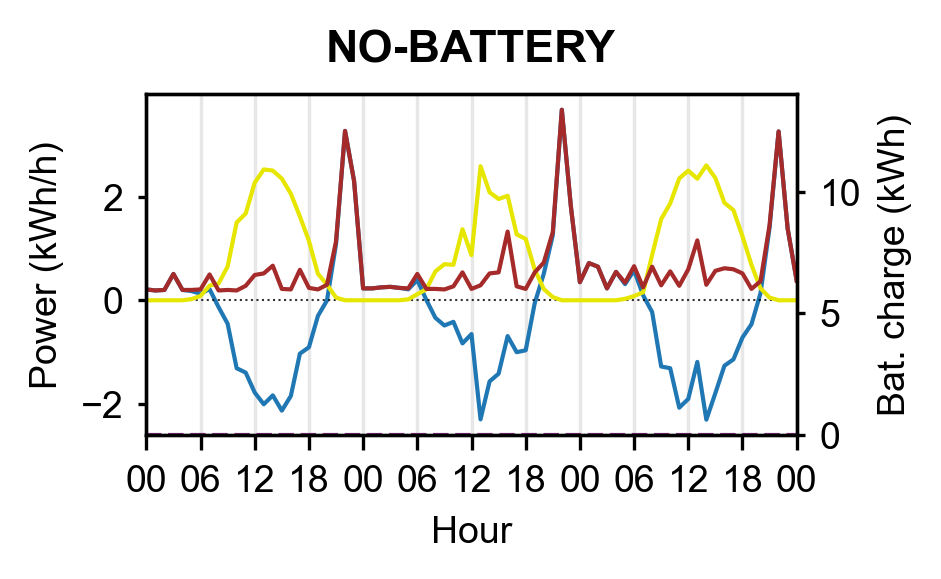

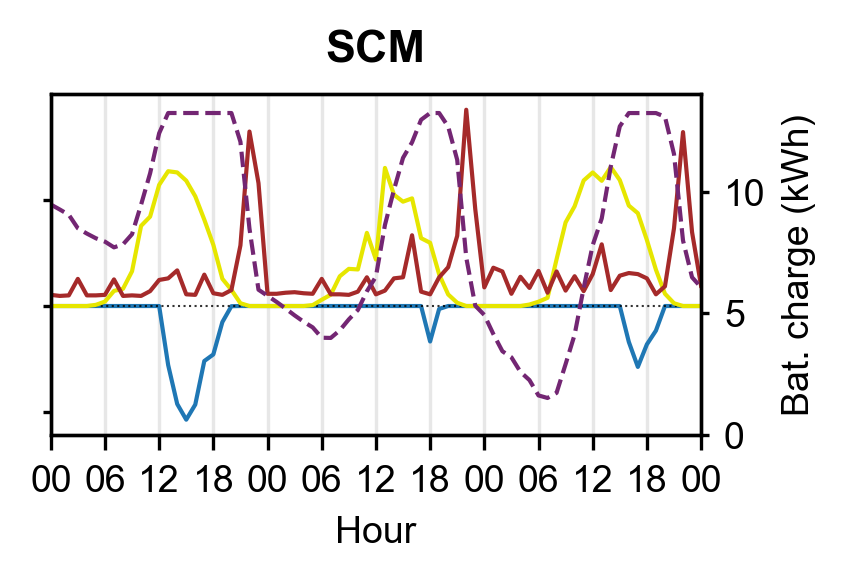

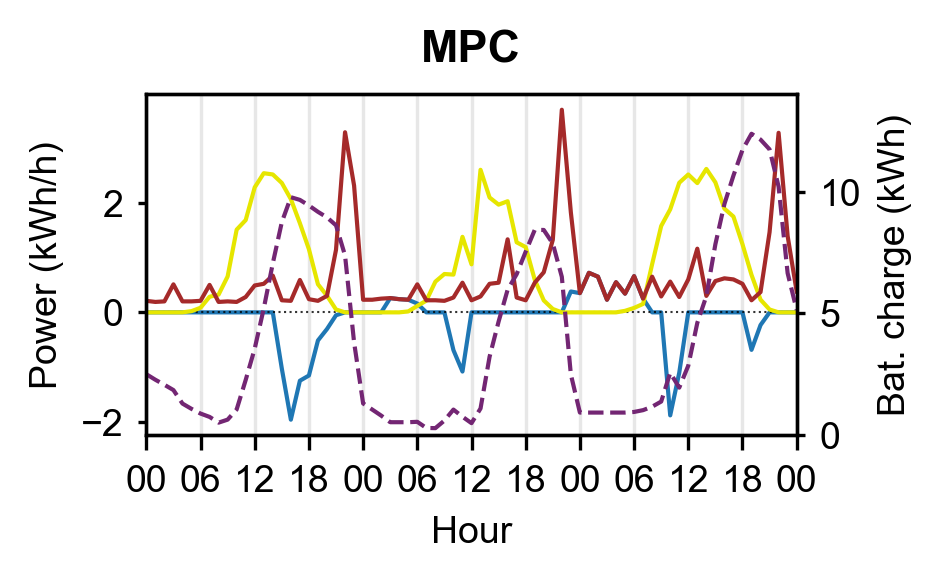

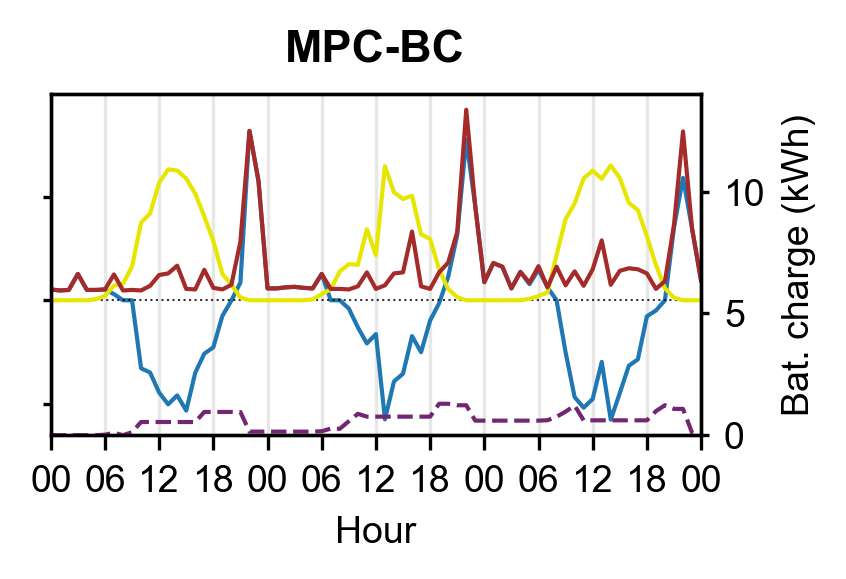

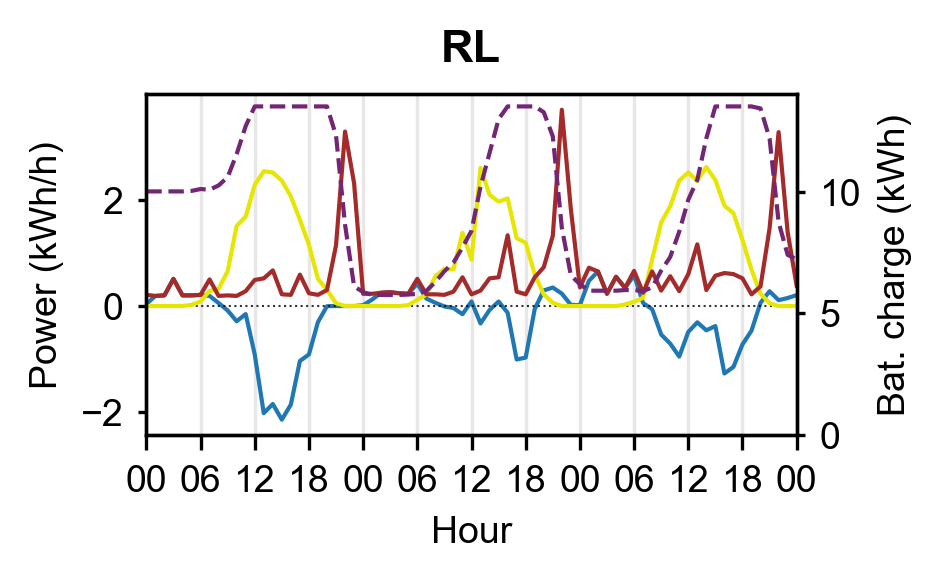

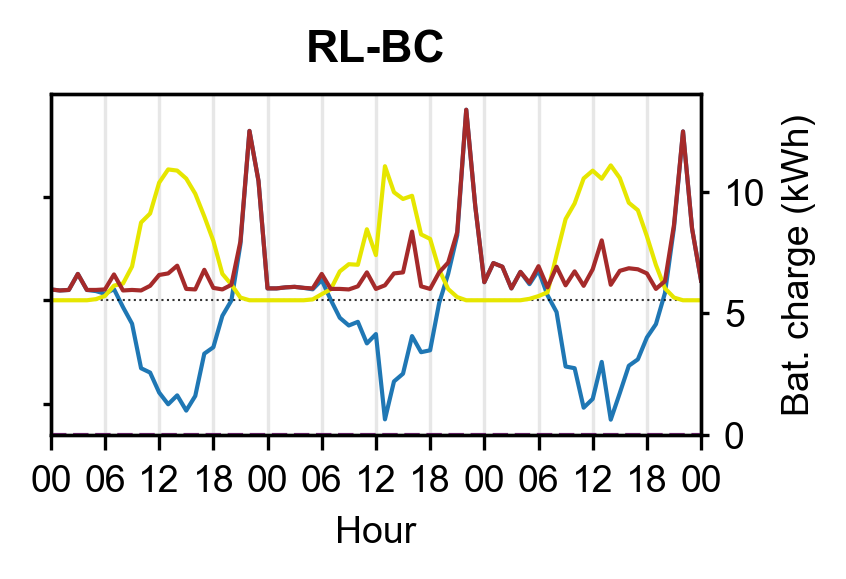

In [3]:
date = datetime.datetime(2021, 7, 10)
name = ''
folder = 'Final_simulations'
plt.rcParams['lines.linewidth'] = 1.
# Set plotting setting
plt.rc('font', size=9)
days = 3
detailed = False
load = 'L9'
figsize=(963/dpi, 700/dpi)
variables = ['power', 'load', 'pv_to_house','pv_to_bat','pv_to_grid','bat_to_house','grid_to_house','pv_to_bat_grid_wasted',
             'to_house_wasted','soc','datetime']


path = f'Results/{folder}/NO-BATTERY_naive_degr_{load}_south_4kWp_{date.year}_UTC03.csv'
ax, fig = plot_days(path, date, days, variables, 'NO-BATTERY', name, save=False, detailed=False, figsize=figsize, net_imports=True, title_y=0.8)
ax.get_legend().remove()

path = f'Results/{folder}/SCM_naive_degr_{load}_south_4kWp_{date.year}_UTC03.csv'
ax, fig = plot_days(path, date, days, variables, 'SCM', name, save=False, detailed=False, figsize=figsize, net_imports=True, title_y=0.8)
ax.get_legend().remove()
ax.set_ylabel(None)
ax.set_yticklabels([])

path = f'Results/{folder}/MPC_naive_degr_{load}_south_4kWp_{date.year}_UTC03.csv'
ax, fig = plot_days(path, date, days, variables, 'MPC', name, save=False, detailed=False, figsize=figsize, net_imports=True, title_y=0.8)
ax.get_legend().remove()

path = f'Results/{folder}/MPC-BC_naive_degr_{load}_south_4kWp_{date.year}_UTC03.csv'
ax, fig = plot_days(path, date, days, variables, 'MPC-BC', name, save=False, detailed=False, figsize=figsize, net_imports=True, title_y=0.8)
ax.get_legend().remove()
ax.set_ylabel(None)
ax.set_yticklabels([])

path = f'Results/{folder}/RL_naive_degr_{load}_south_4kWp_{date.year}_UTC03.csv'
ax, fig = plot_days(path, date, days, variables, 'RL', name, save=False, detailed=False, figsize=figsize, net_imports=True, title_y=0.8)
ax.get_legend().remove()

path = f'Results/{folder}/RL-BC_naive_degr_{load}_south_4kWp_{date.year}_UTC03.csv'
ax, fig = plot_days(path, date, days, variables, 'RL-BC', name, save=False, detailed=False, figsize=figsize, net_imports=True, title_y=0.8)
ax.get_legend().remove()
ax.set_ylabel(None)
ax.set_yticklabels([])

Text(0.5, 1, 'Spot prices')

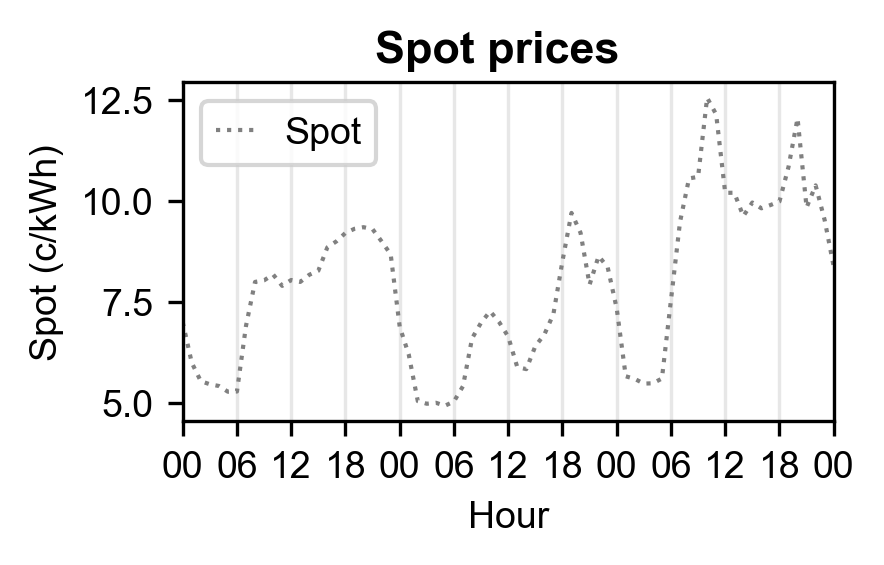

In [4]:
year = date.year
data = pd.read_csv(path, parse_dates=['datetime'])

# Select variables to be used
data = data[['datetime', 'spot']]

start = date
end = date + datetime.timedelta(days=days)
data = data[(data.datetime>=start)&(data.datetime<=end)]

figsize=(840/dpi, 440/dpi)
fig, ax = plt.subplots(1,1, figsize=figsize, dpi=300, sharex=False, sharey=True)
ax.plot(data.datetime, data.spot, label='Spot', color='grey', linestyle=':')
ax.grid(axis='x', alpha=0.3)
ax.set_xlim(data.datetime.iloc[0], data.datetime.iloc[-1])
# Format primary x-axis ticks with hourly resolution
ax.xaxis.set_major_locator(mdates.HourLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H'))
ax.legend(loc='upper left', bbox_to_anchor=(0,1), handlelength=1, columnspacing=0.4)
ax.set_xlabel('Hour')
ax.set_ylabel('Spot (c/kWh)')
fig.suptitle('Spot prices', weight='bold', y=1)


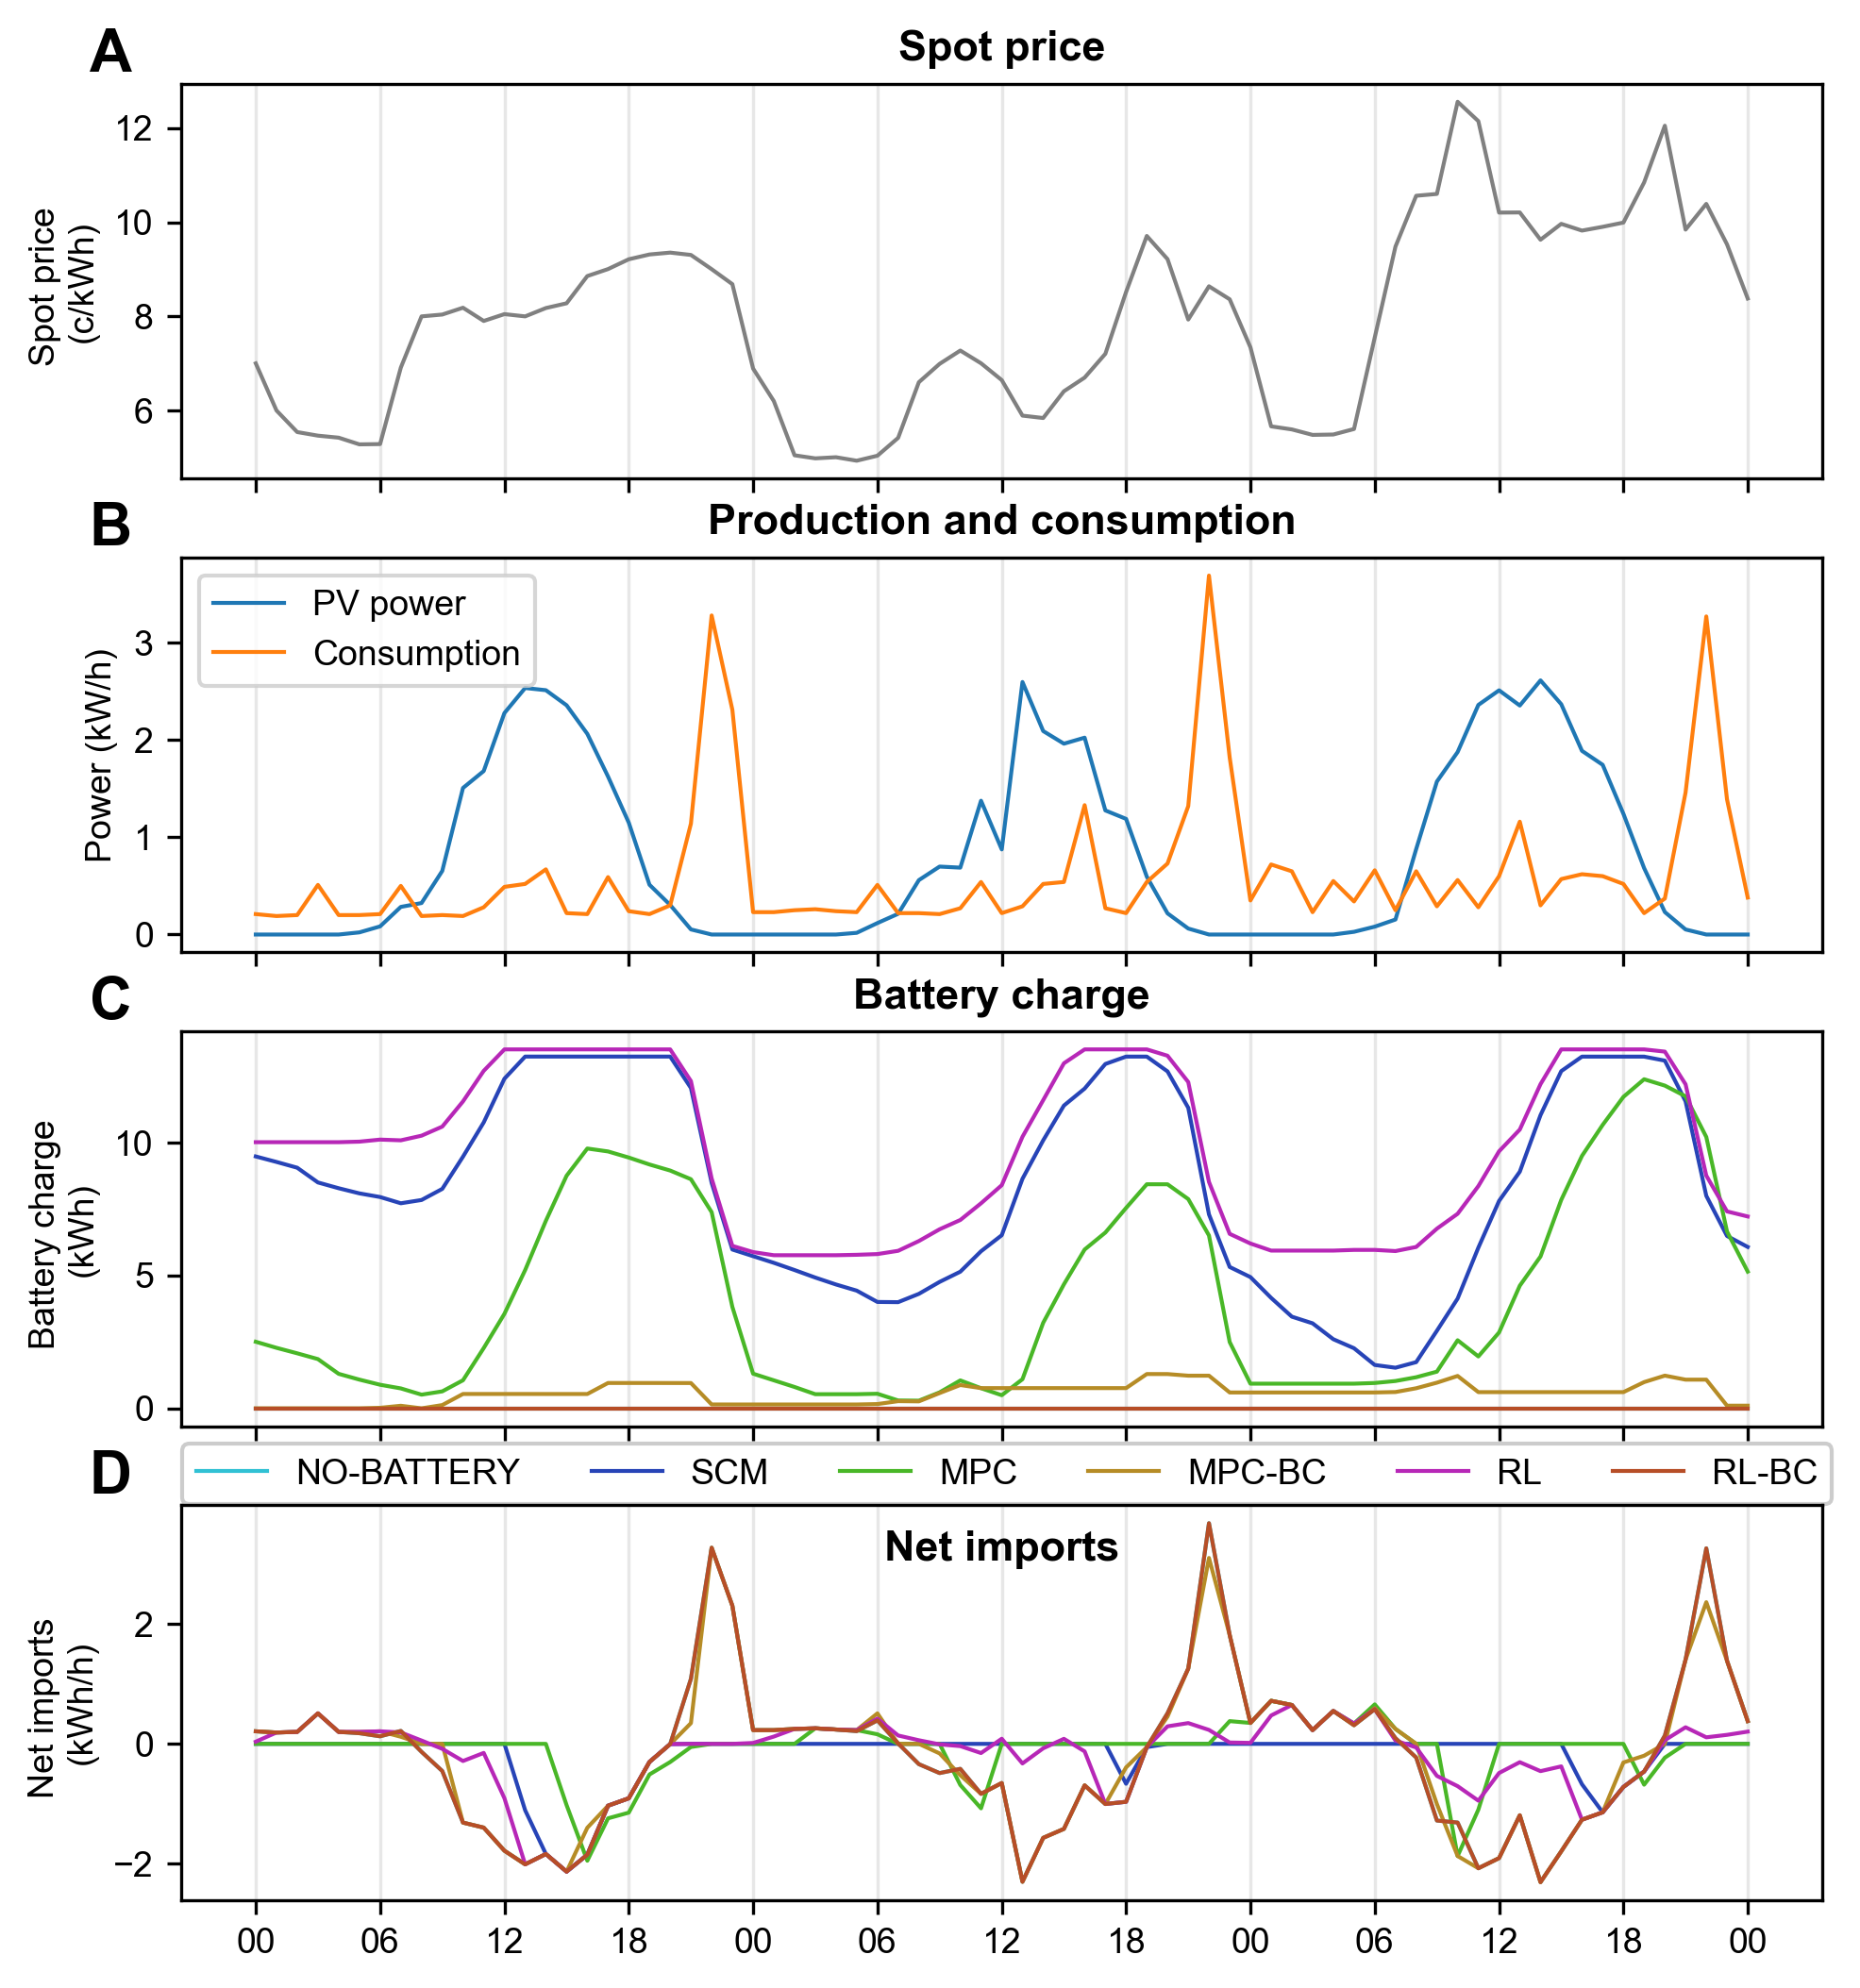

In [5]:
date = datetime.datetime(2021, 7, 10)
name = ''
plt.rcParams['lines.linewidth'] = 1.
# Set plotting setting
plt.rc('font', size=9)
days = 3
detailed = False
load = 'L9'
figsize=(2244/dpi, 2500/dpi)
fig, ax = plt.subplots(4, 1, figsize=figsize, sharex=True, dpi=300)

folder = 'Final_simulations'

no_bat = pd.read_csv(f'Results/{folder}/NO-BATTERY_naive_degr_L9_south_4kWp_2021_UTC03.csv', parse_dates=['datetime'])
scm = pd.read_csv(f'Results/{folder}/SCM_naive_degr_L9_south_4kWp_2021_UTC03.csv', parse_dates=['datetime'])
mpc = pd.read_csv(f'Results/{folder}/MPC_naive_degr_L9_south_4kWp_2021_UTC03.csv', parse_dates=['datetime'])
mpcbc = pd.read_csv(f'Results/{folder}/MPC-BC_naive_degr_L9_south_4kWp_2021_UTC03.csv', parse_dates=['datetime'])
rl = pd.read_csv(f'Results/{folder}/RL_naive_degr_L9_south_4kWp_2021_UTC03.csv', parse_dates=['datetime'])
rlbc = pd.read_csv(f'Results/{folder}/RL-BC_naive_degr_L9_south_4kWp_2021_UTC03.csv', parse_dates=['datetime'])

start = date
end = date + datetime.timedelta(days=days)

no_bat = no_bat[(no_bat.datetime>=start)&(no_bat.datetime<=end)]
scm = scm[(scm.datetime>=start)&(scm.datetime<=end)]
mpc = mpc[(mpc.datetime>=start)&(mpc.datetime<=end)]
mpcbc = mpcbc[(mpcbc.datetime>=start)&(mpcbc.datetime<=end)]
rl = rl[(rl.datetime>=start)&(rl.datetime<=end)]
rlbc = rlbc[(rlbc.datetime>=start)&(rlbc.datetime<=end)]

for df in [no_bat, scm, mpc, mpcbc, rl, rlbc]:
    df['net_imports'] = df.grid_to_house - df.pv_to_grid

ax[0].plot(no_bat.datetime, no_bat.spot, color='grey')
ax[0].set_ylabel('Spot price \n(c/kWh)')
ax[0].set_title('Spot price', weight='bold')

ax[1].plot(no_bat.datetime, no_bat.power, label='PV power')
ax[1].plot(no_bat.datetime, no_bat.load, label='Consumption')
ax[1].set_ylabel('Power (kW/h)')
ax[1].set_title('Production and consumption', weight='bold')
ax[1].legend()

ax[2].plot(no_bat.datetime, no_bat.soc, color="#31C1D4", label='NO-BATTERY')
ax[2].plot(scm.datetime, scm.soc, color='#2744B7', label='SCM')
ax[2].plot(mpc.datetime, mpc.soc, color='#49B727', label='MPC')
ax[2].plot(mpcbc.datetime, mpcbc.soc, color='#B68C26', label='MPC-BC')
ax[2].plot(rl.datetime, rl.soc, color='#B727B7', label='RL')
ax[2].plot(rlbc.datetime, rlbc.soc, color='#B74E27', label='RL-BC')
ax[2].set_ylabel('Battery charge \n(kWh)')
ax[2].set_title('Battery charge', weight='bold')
ax[2].legend(ncols=6, loc='upper left', bbox_to_anchor=(-0.01,-0.0), framealpha=1)

ax[3].plot(no_bat.datetime, no_bat.net_imports, color="#31C1D4")
ax[3].plot(scm.datetime, scm.net_imports, color='#2744B7')
ax[3].plot(mpc.datetime, mpc.net_imports, color='#49B727')
ax[3].plot(mpcbc.datetime, mpcbc.net_imports, color='#B68C26')
ax[3].plot(rl.datetime, rl.net_imports, color='#B727B7')
ax[3].plot(rlbc.datetime, rlbc.net_imports, color='#B74E27')
ax[3].set_ylabel('Net imports \n(kWh/h)')
ax[3].set_title('Net imports', weight='bold', x=0.5, y=0.8)

# Format primary x-axis ticks with hourly resolution
ax[3].xaxis.set_major_locator(mdates.HourLocator(byhour=[0, 6, 12, 18]))
ax[3].xaxis.set_major_formatter(mdates.DateFormatter('%H'))

for a, letter in list(zip([ax[0], ax[1], ax[2], ax[3]], 
                        ['A', 'B', 'C', 'D'])):
    x0, xmax = a.set_xlim()
    y0, ymax = a.set_ylim()
    data_width = xmax - x0
    data_height = ymax - y0
    a.text(x0-(0.03*data_width), (y0 + 1*data_height), letter, weight='bold', fontsize=15, va='bottom', ha='right')
    a.grid(axis='x', alpha=0.3)

plt.show()

## Battery break-even CAPEX

In [7]:
# Read data
file = 'Results.csv'
data = pd.read_csv(os.path.join('Results', 'Compiled_results', file))
data = data[(data.degradation == 'degr') & (~data.strategy.isin(['MILP-YEAR']))]
# Calculate the electricity bill difference between a given strategy and no battery 

# Create a new DataFrame for the "NO-BATTERY" strategy
df_no_battery = data[data['strategy'] == 'NO-BATTERY'].copy()

# Rename the 'el_bill' column to 'el_bill_no_battery' for clarity
df_no_battery = df_no_battery.rename(columns={'el_bill': 'el_bill_no_battery'})

# Merge the original DataFrame with the 'NO-BATTERY' DataFrame on the relevant columns
# The relevant columns are all columns except 'strategy' and 'el_bill'
merge_columns = [col for col in data.columns if col in ['year', 'load_profile', 'pv_capacity', 'pv_tot', 'forecast', 'degradation']]

df_merged = pd.merge(data, df_no_battery[merge_columns + ['el_bill_no_battery']],
                     on=merge_columns, how='left')

# Calculate the new column 'el_bill_difference'
df_merged['el_bill_difference'] = df_merged['el_bill_no_battery'] - df_merged['el_bill']
df_merged['total_cost_difference'] = df_merged['el_bill_no_battery'] - df_merged['total_cost']

# Drop the 'el_bill_no_battery' column as it's no longer needed
df_merged = df_merged.drop(columns=['el_bill_no_battery'])

# df_merged is now the DataFrame with the new column added
# Create a new column representing the break-even CAPEX

data_all = data.copy()
data_all['el_bill_savings'] = df_merged['el_bill_difference'].values
data_all['break_even_CAPEX'] = data_all['el_bill_savings']/data_all['delta_SOH']/13.5
data_all

,strategy,forecast,year,load_profile,load_tot,pv_profile,pv_capacity,pv_tot,bat_capacity,degradation,...,aging_factor_float,aging_factor_cyc,scr,ssr,wasted_energy,el_bill,bat_usage_cost,total_cost,el_bill_savings,break_even_CAPEX
12,MPC-BC,naive,2020,L11,17392.890,south,4kWp,3540.475387,13.500000,degr,...,0.034106,0.002074,0.731816,0.148968,4.969442e-12,1380.124393,307.851705,1687.976098,10.151596,21.983735
13,MPC-BC,naive,2021,L11,19023.690,south,4kWp,3220.615457,13.407644,degr,...,0.034007,0.002009,0.708387,0.119926,7.210639e-07,2632.684930,305.080312,2937.765242,11.646979,25.451175
14,MPC-BC,naive,2022,L11,16640.280,south,4kWp,3415.314379,13.316120,degr,...,0.034187,0.004869,0.722288,0.148245,1.183675e-11,2974.329595,328.984573,3303.314168,67.163668,136.102974
15,MPC-BC,naive,2020,L12,15158.440,south,4kWp,3540.475387,13.500000,degr,...,0.034091,0.001956,0.699465,0.163370,3.776451e-12,1218.188420,307.981028,1526.169447,10.132154,21.932420
16,MPC-BC,naive,2021,L12,16559.940,south,4kWp,3220.615457,13.407606,degr,...,0.034008,0.002014,0.698428,0.135832,5.952017e-12,2240.042249,305.911819,2545.954067,11.972463,26.091315
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79,SCM,naive,2021,L13,19219.510,south,4kWp,3220.615457,13.315875,degr,...,0.035304,0.029041,0.993075,0.166410,0.000000e+00,2324.535275,549.590027,2874.125302,72.988325,88.536693
80,SCM,naive,2022,L13,22059.460,south,4kWp,3415.314379,13.150998,degr,...,0.036215,0.036888,0.970806,0.150303,0.000000e+00,3924.699221,616.595910,4541.295131,65.630275,70.959791
81,SCM,naive,2020,L9,11900.270,south,4kWp,3540.475387,13.500000,degr,...,0.036977,0.029833,0.935735,0.278392,0.000000e+00,841.542594,578.973506,1420.516100,71.637645,82.488109
82,SCM,naive,2021,L9,13508.490,south,4kWp,3220.615457,13.326308,degr,...,0.037599,0.029363,0.909662,0.216876,0.000000e+00,1748.171249,573.169887,2321.341136,64.088961,74.543298


In [13]:
data = data_all[data_all['load_profile']=='L9']
data = data.rename(columns={'pv_profile':'Profile', 'bat_usage_cost':'Bat. cost', 'el_bill':'El. bill'})
data_new = data.melt(id_vars=['strategy', 'year', 'load_profile', 'Profile'], value_vars=['break_even_CAPEX'])
data_new = data_new.rename(columns={'variable':'break-even'})

print(data_new)

alt.Chart(data_new).mark_bar().encode(
    x=alt.X('strategy:N', title=None, sort=['NO-BATTERY', 'SCM', 'MPC', 'MPC-BC', 'RL', 'RL-BC']),   
    y=alt.Y('sum(value):Q',axis=alt.Axis(grid=True, title='Break-even CAPEX (EUR/kWh)', 
                                          titleFontStyle='normal', titleFontSize=10, labelAngle=0)),    
    column=alt.Column('year:N', title=None, spacing=5).header(labelFontSize=10, labelFont='arial'),   
    color=alt.Color('break-even:N', scale=alt.Scale(range=colors3)).legend(None),   
    xOffset=alt.XOffset("Profile:N")
    ).configure_view(     
            # remove grid lines around column clusters
            strokeOpacity=0).properties(
                width=89,
                height=100
            ).configure_axis(
                labelFontSize=7,
                titleFontSize=10,
                labelFont='arial',
                titleFont='arial',
                labelAngle=45
            ).configure_range(category=alt.RangeScheme(colors3)
            )

      strategy  year load_profile Profile        break-even         value
0       MPC-BC  2020           L9   south  break_even_CAPEX  2.561594e+01
1       MPC-BC  2021           L9   south  break_even_CAPEX  2.735958e+01
2       MPC-BC  2022           L9   south  break_even_CAPEX  1.479222e+02
3          MPC  2020           L9   south  break_even_CAPEX  7.996157e+01
4          MPC  2021           L9   south  break_even_CAPEX  7.851287e+01
5          MPC  2022           L9   south  break_even_CAPEX  1.854270e+02
6   NO-BATTERY  2020           L9   south  break_even_CAPEX           NaN
7   NO-BATTERY  2021           L9   south  break_even_CAPEX           NaN
8   NO-BATTERY  2022           L9   south  break_even_CAPEX           NaN
9        RL-BC  2020           L9   south  break_even_CAPEX -5.526811e-07
10       RL-BC  2021           L9   south  break_even_CAPEX  1.692729e-06
11       RL-BC  2022           L9   south  break_even_CAPEX -1.569505e-08
12          RL  2020           L9   so

alt.Chart(...)

In [14]:
data = data_all[data_all['load_profile']=='L11']
data = data.rename(columns={'pv_profile':'Profile', 'bat_usage_cost':'Bat. cost', 'el_bill':'El. bill'})
data_new = data.melt(id_vars=['strategy', 'year', 'load_profile', 'Profile'], value_vars=['break_even_CAPEX'])
data_new = data_new.rename(columns={'variable':'break-even'})

print(data_new)

alt.Chart(data_new).mark_bar().encode(
    x=alt.X('strategy:N', title=None, sort=['NO-BATTERY', 'SCM', 'MPC', 'MPC-BC', 'RL', 'RL-BC']),   
    y=alt.Y('sum(value):Q',axis=alt.Axis(grid=True, title='Break-even CAPEX (EUR/kWh)', 
                                          titleFontStyle='normal', titleFontSize=10, labelAngle=0)),    
    column=alt.Column('year:N', title=None, spacing=5).header(labelFontSize=10, labelFont='arial'),   
    color=alt.Color('break-even:N', scale=alt.Scale(range=colors3)).legend(None),   
    xOffset=alt.XOffset("Profile:N")
    ).configure_view(     
            # remove grid lines around column clusters
            strokeOpacity=0).properties(
                width=89,
                height=100
            ).configure_axis(
                labelFontSize=7,
                titleFontSize=10,
                labelFont='arial',
                titleFont='arial',
                labelAngle=45
            ).configure_range(category=alt.RangeScheme(colors3)
            )

      strategy  year load_profile Profile        break-even       value
0       MPC-BC  2020          L11   south  break_even_CAPEX   21.983735
1       MPC-BC  2021          L11   south  break_even_CAPEX   25.451175
2       MPC-BC  2022          L11   south  break_even_CAPEX  136.102974
3          MPC  2020          L11   south  break_even_CAPEX   55.852353
4          MPC  2021          L11   south  break_even_CAPEX   54.021196
5          MPC  2022          L11   south  break_even_CAPEX  168.223348
6   NO-BATTERY  2020          L11   south  break_even_CAPEX         NaN
7   NO-BATTERY  2021          L11   south  break_even_CAPEX         NaN
8   NO-BATTERY  2022          L11   south  break_even_CAPEX         NaN
9        RL-BC  2020          L11   south  break_even_CAPEX    0.000002
10       RL-BC  2021          L11   south  break_even_CAPEX   -0.000004
11       RL-BC  2022          L11   south  break_even_CAPEX   -0.000003
12          RL  2020          L11   south  break_even_CAPEX   63

alt.Chart(...)

In [15]:
data = data_all[data_all['load_profile']=='L12']
data = data.rename(columns={'pv_profile':'Profile', 'bat_usage_cost':'Bat. cost', 'el_bill':'El. bill'})
data_new = data.melt(id_vars=['strategy', 'year', 'load_profile', 'Profile'], value_vars=['break_even_CAPEX'])
data_new = data_new.rename(columns={'variable':'break-even'})

print(data_new)

alt.Chart(data_new).mark_bar().encode(
    x=alt.X('strategy:N', title=None, sort=['NO-BATTERY', 'SCM', 'MPC', 'MPC-BC', 'RL', 'RL-BC']),   
    y=alt.Y('sum(value):Q',axis=alt.Axis(grid=True, title='Break-even CAPEX (EUR/kWh)', 
                                          titleFontStyle='normal', titleFontSize=10, labelAngle=0)),    
    column=alt.Column('year:N', title=None, spacing=5).header(labelFontSize=10, labelFont='arial'),   
    color=alt.Color('break-even:N', scale=alt.Scale(range=colors3)).legend(None),   
    xOffset=alt.XOffset("Profile:N")
    ).configure_view(     
            # remove grid lines around column clusters
            strokeOpacity=0).properties(
                width=89,
                height=100
            ).configure_axis(
                labelFontSize=7,
                titleFontSize=10,
                labelFont='arial',
                titleFont='arial',
                labelAngle=45
            ).configure_range(category=alt.RangeScheme(colors3)
            )

      strategy  year load_profile Profile        break-even       value
0       MPC-BC  2020          L12   south  break_even_CAPEX   21.932420
1       MPC-BC  2021          L12   south  break_even_CAPEX   26.091315
2       MPC-BC  2022          L12   south  break_even_CAPEX  133.292545
3          MPC  2020          L12   south  break_even_CAPEX   65.412059
4          MPC  2021          L12   south  break_even_CAPEX   61.568476
5          MPC  2022          L12   south  break_even_CAPEX  167.646862
6   NO-BATTERY  2020          L12   south  break_even_CAPEX         NaN
7   NO-BATTERY  2021          L12   south  break_even_CAPEX         NaN
8   NO-BATTERY  2022          L12   south  break_even_CAPEX         NaN
9        RL-BC  2020          L12   south  break_even_CAPEX    0.000003
10       RL-BC  2021          L12   south  break_even_CAPEX    0.000001
11       RL-BC  2022          L12   south  break_even_CAPEX   -0.000003
12          RL  2020          L12   south  break_even_CAPEX   77

alt.Chart(...)

In [16]:
data = data_all[data_all['load_profile']=='L13']
data = data.rename(columns={'pv_profile':'Profile', 'bat_usage_cost':'Bat. cost', 'el_bill':'El. bill'})
data_new = data.melt(id_vars=['strategy', 'year', 'load_profile', 'Profile'], value_vars=['break_even_CAPEX'])
data_new = data_new.rename(columns={'variable':'break-even'})

print(data_new)

alt.Chart(data_new).mark_bar().encode(
    x=alt.X('strategy:N', title=None, sort=['NO-BATTERY', 'SCM', 'MPC', 'MPC-BC', 'RL', 'RL-BC']),   
    y=alt.Y('sum(value):Q',axis=alt.Axis(grid=True, title='Break-even CAPEX (EUR/kWh)', 
                                          titleFontStyle='normal', titleFontSize=10, labelAngle=0)),    
    column=alt.Column('year:N', title=None, spacing=5).header(labelFontSize=10, labelFont='arial'),   
    color=alt.Color('break-even:N', scale=alt.Scale(range=colors3)).legend(None),   
    xOffset=alt.XOffset("Profile:N")
    ).configure_view(     
            # remove grid lines around column clusters
            strokeOpacity=0).properties(
                width=89,
                height=100
            ).configure_axis(
                labelFontSize=7,
                titleFontSize=10,
                labelFont='arial',
                titleFont='arial',
                labelAngle=45
            ).configure_range(category=alt.RangeScheme(colors3)
            )

      strategy  year load_profile Profile        break-even       value
0       MPC-BC  2020          L13   south  break_even_CAPEX   25.972652
1       MPC-BC  2021          L13   south  break_even_CAPEX   25.617239
2       MPC-BC  2022          L13   south  break_even_CAPEX  131.208924
3          MPC  2020          L13   south  break_even_CAPEX   88.816861
4          MPC  2021          L13   south  break_even_CAPEX   83.592687
5          MPC  2022          L13   south  break_even_CAPEX  168.045142
6   NO-BATTERY  2020          L13   south  break_even_CAPEX         NaN
7   NO-BATTERY  2021          L13   south  break_even_CAPEX         NaN
8   NO-BATTERY  2022          L13   south  break_even_CAPEX         NaN
9        RL-BC  2020          L13   south  break_even_CAPEX    0.000004
10       RL-BC  2021          L13   south  break_even_CAPEX    0.000005
11       RL-BC  2022          L13   south  break_even_CAPEX   -0.000002
12          RL  2020          L13   south  break_even_CAPEX   87

alt.Chart(...)

## Float vs cyclic degradation

In [ ]:
# Read data
file = 'Results.csv'
data = pd.read_csv(os.path.join('Results', 'Compiled_results', file))
data = data[(data.degradation == 'degr') & (~data.strategy.isin(['MILP-YEAR', 'MILP-ENERGY-ARBITRAGE-YEAR']))]

data = data.replace({'L9':'L1', 'L11':'L2', 'L12':'L3', 'L13':'L4'})
data_all = data.sort_values('load_profile')

data = data_all[data_all['load_profile']=='L1']
data = data.rename(columns={'pv_profile':'Profile', 'delta_SOH_cyc':'Cyclic', 'delta_SOH_float':'Float'})
data_new = data.melt(id_vars=['strategy', 'year', 'load_profile', 'Profile'], value_vars=['Cyclic', 'Float'])
data_new = data_new.rename(columns={'variable':'Cost'})

alt.Chart(data_new).mark_bar().encode(
    x=alt.X('strategy:N', title=None, sort=['NO-BATTERY', 'SCM', 'MPC', 'MPC-BC', 'RL', 'RL-BC']), 
    y=alt.Y('sum(value):Q', axis=alt.Axis(grid=True, title='ΔSOH (-)', 
                                          titleFontStyle='normal', titleFontSize=10, labelAngle=0)),    
    column=alt.Column('year:N', title=None, spacing=5).header(labelFontSize=10, labelFont='arial'),   
    color=alt.Color('Cost:N', scale=alt.Scale(range=colors3)).legend(orient='none', labelFontSize=9, labelFont='arial', legendX=-20, legendY=-20, title='', titleFontSize=10, titleFont='arial'),   
    xOffset=alt.XOffset("Profile:N")
    ).configure_view(     
            # remove grid lines around column clusters
            strokeOpacity=0).properties(
                width=89,
                height=100
            ).configure_axis(
                labelFontSize=7,
                titleFontSize=10,
                labelFont='arial',
                titleFont='arial',
                labelAngle=45
            ).configure_range(category=alt.RangeScheme(colors3)
            )

alt.Chart(...)

In [18]:
data = data_all[data_all['load_profile']=='L2']
data = data.rename(columns={'pv_profile':'Profile', 'delta_SOH_cyc':'Cyclic', 'delta_SOH_float':'Float'})
data_new = data.melt(id_vars=['strategy', 'year', 'load_profile', 'Profile'], value_vars=['Cyclic', 'Float'])
data_new = data_new.rename(columns={'variable':'Cost'})

alt.Chart(data_new).mark_bar().encode(
    x=alt.X('strategy:N', title=None, sort=['NO-BATTERY', 'SCM', 'MPC', 'MPC-BC', 'RL', 'RL-BC']), 
    y=alt.Y('sum(value):Q', axis=alt.Axis(grid=True, title='ΔSOH (-)', 
                                          titleFontStyle='normal', titleFontSize=10, labelAngle=0)),    
    column=alt.Column('year:N', title=None, spacing=5).header(labelFontSize=10, labelFont='arial'),   
    color=alt.Color('Cost:N', scale=alt.Scale(range=colors3)).legend(orient='none', labelFontSize=9, labelFont='arial', legendX=-20, legendY=-20, title='', titleFontSize=10, titleFont='arial'),   
    xOffset=alt.XOffset("Profile:N")
    ).configure_view(     
            # remove grid lines around column clusters
            strokeOpacity=0).properties(
                width=89,
                height=100
            ).configure_axis(
                labelFontSize=7,
                titleFontSize=10,
                labelFont='arial',
                titleFont='arial',
                labelAngle=45
            ).configure_range(category=alt.RangeScheme(colors3)
            )

alt.Chart(...)

In [19]:
data = data_all[data_all['load_profile']=='L3']
data = data.rename(columns={'pv_profile':'Profile', 'delta_SOH_cyc':'Cyclic', 'delta_SOH_float':'Float'})
data_new = data.melt(id_vars=['strategy', 'year', 'load_profile', 'Profile'], value_vars=['Cyclic', 'Float'])
data_new = data_new.rename(columns={'variable':'Cost'})

alt.Chart(data_new).mark_bar().encode(
    x=alt.X('strategy:N', title=None, sort=['NO-BATTERY', 'SCM', 'MPC', 'MPC-BC', 'RL', 'RL-BC']), 
    y=alt.Y('sum(value):Q', axis=alt.Axis(grid=True, title='ΔSOH (-)', 
                                          titleFontStyle='normal', titleFontSize=10, labelAngle=0)),    
    column=alt.Column('year:N', title=None, spacing=5).header(labelFontSize=10, labelFont='arial'),   
    color=alt.Color('Cost:N', scale=alt.Scale(range=colors3)).legend(orient='none', labelFontSize=9, labelFont='arial', legendX=-20, legendY=-20, title='', titleFontSize=10, titleFont='arial'),   
    xOffset=alt.XOffset("Profile:N")
    ).configure_view(     
            # remove grid lines around column clusters
            strokeOpacity=0).properties(
                width=89,
                height=100
            ).configure_axis(
                labelFontSize=7,
                titleFontSize=10,
                labelFont='arial',
                titleFont='arial',
                labelAngle=45
            ).configure_range(category=alt.RangeScheme(colors3)
            )

alt.Chart(...)

In [20]:
data = data_all[data_all['load_profile']=='L4']
data = data.rename(columns={'pv_profile':'Profile', 'delta_SOH_cyc':'Cyclic', 'delta_SOH_float':'Float'})
data_new = data.melt(id_vars=['strategy', 'year', 'load_profile', 'Profile'], value_vars=['Cyclic', 'Float'])
data_new = data_new.rename(columns={'variable':'Cost'})

alt.Chart(data_new).mark_bar().encode(
    x=alt.X('strategy:N', title=None, sort=['NO-BATTERY', 'SCM', 'MPC', 'MPC-BC', 'RL', 'RL-BC']), 
    y=alt.Y('sum(value):Q', axis=alt.Axis(grid=True, title='ΔSOH (-)', 
                                          titleFontStyle='normal', titleFontSize=10, labelAngle=0)),    
    column=alt.Column('year:N', title=None, spacing=5).header(labelFontSize=10, labelFont='arial'),   
    color=alt.Color('Cost:N', scale=alt.Scale(range=colors3)).legend(orient='none', labelFontSize=9, labelFont='arial', legendX=-20, legendY=-20, title='', titleFontSize=10, titleFont='arial'),   
    xOffset=alt.XOffset("Profile:N")
    ).configure_view(     
            # remove grid lines around column clusters
            strokeOpacity=0).properties(
                width=89,
                height=100
            ).configure_axis(
                labelFontSize=7,
                titleFontSize=10,
                labelFont='arial',
                titleFont='arial',
                labelAngle=45
            ).configure_range(category=alt.RangeScheme(colors3)
            )

alt.Chart(...)